# Ghost-partition PINN flux reconstruction — nonconforming fracture mesh

This notebook repeats the MMS/LCG/PINN workflow with a nonconforming fracture mesh.  The bulk is a thin pseudo-3D slab, while the fracture is an independent 1D mesh coupled with `fenicsx_ii`.


## Manufactured Solution (MMS)

The current `fenicsx_ii` restriction operators still assume a 3D ambient mesh for a 1D fracture.  To represent the 2D fracture model, the unit square is extruded to a thin slab, the permeability in the \(z\)-direction is set to zero, and the bulk terms are divided by the slab thickness.  This makes the slab integral equal to the projected 2D integral while keeping the multiplier in the same units as the 2D LCG formulation.

The fracture is intentionally independent of the bulk mesh.  We use a smooth background pressure \(q(x,y)=\sin(\pi x)\sin(\pi y)\) and a kink across the fracture line,
\[
p_m(x,y)=q(x,y)+\alpha |r(x,y)|q(x,y),
\]
where \(r\) is the signed distance to the fracture.  The fracture pressure is the trace \(p_\Gamma=q|_\Gamma\), and the paper-sign multiplier is \(\lambda=-2\alpha q|_\Gamma\).


## 0. Convergence analysis

Run the nonconforming pseudo-3D LCG MMS solve for the refinement levels in `CONV_REFS`.  The default Section 0 setup follows the Martin/Koppel P1 multiplier case: P1 matrix pressure, P1 fracture pressure, P1 multiplier, and `h_Gamma = h_lambda ~= h/2`.  The same setup function is reused below to build the single reference solution for the PINN reconstruction cells.



--- nonconforming LCG MMS convergence ref=2 ---
reading supplied bulk mesh Omega_ex1_2.msh
Info    : Reading 'Omega_ex1_2.msh'...
Info    : 27 entities
Info    : 162 nodes
Info    : 64 elements
Info    : Done reading 'Omega_ex1_2.msh'
reading cached fracture mesh for ref=2, h=1.250e-01
Info    : Reading 'fracture_problem_nonconforming/meshes/gamma_omega_ex1_ref2_h0p12500000_a0p000_0p000_b1p000_1p000_th0p020_flc0p500.msh'...
Info    : 3 entities
Info    : 24 nodes
Info    : 23 elements
Info    : Done reading 'fracture_problem_nonconforming/meshes/gamma_omega_ex1_ref2_h0p12500000_a0p000_0p000_b1p000_1p000_th0p020_flc0p500.msh'
h=1.250e-01, h_Gamma=h_lambda=6.149e-02, total dofs=210, err_pm=1.164e-01, err_pf=1.787e-01, err_lambda_h_tip=2.087e+03


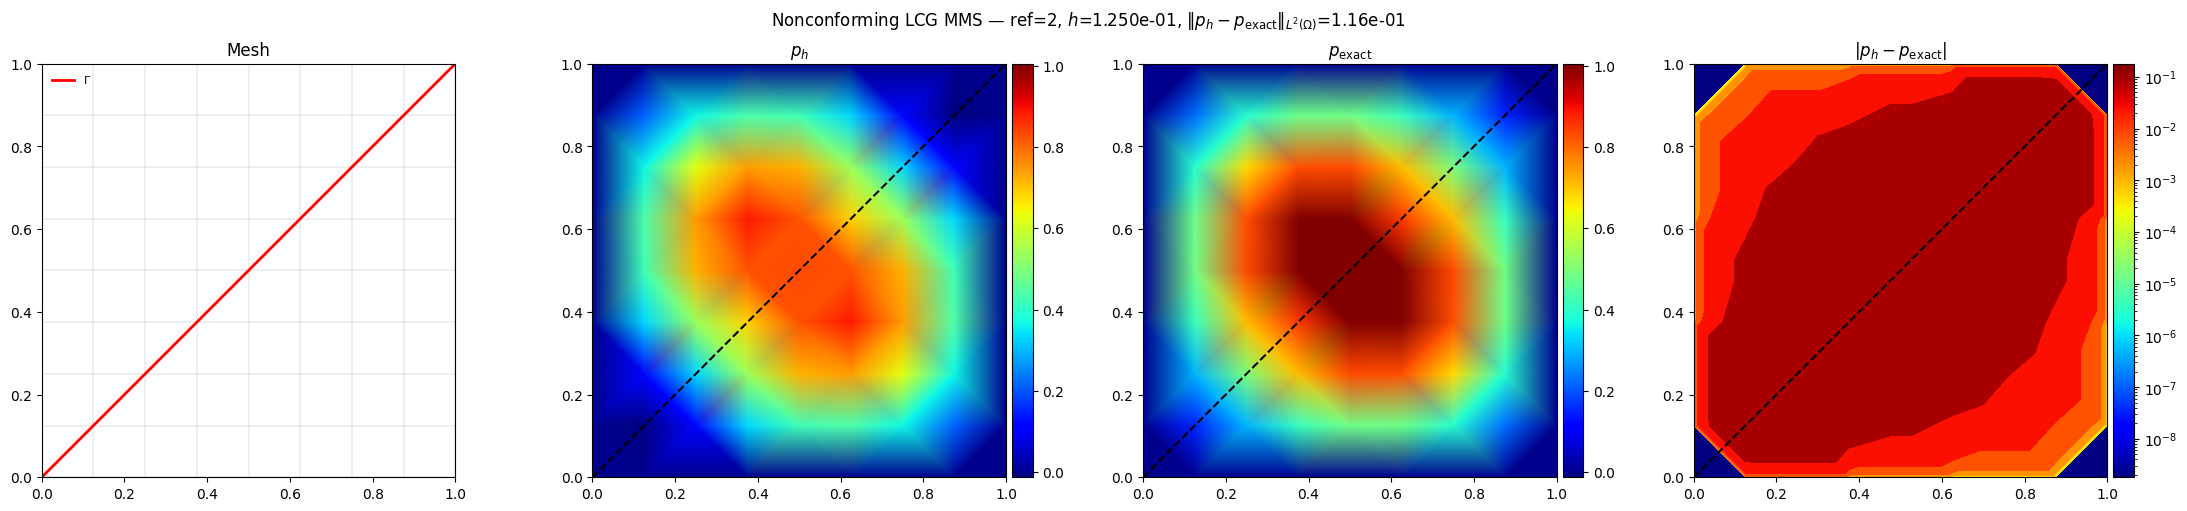


--- nonconforming LCG MMS convergence ref=3 ---
reading supplied bulk mesh Omega_ex1_3.msh
Info    : Reading 'Omega_ex1_3.msh'...
Info    : 27 entities
Info    : 578 nodes
Info    : 256 elements
Info    : Done reading 'Omega_ex1_3.msh'
reading cached fracture mesh for ref=3, h=6.250e-02
Info    : Reading 'fracture_problem_nonconforming/meshes/gamma_omega_ex1_ref3_h0p06250000_a0p000_0p000_b1p000_1p000_th0p020_flc0p500.msh'...
Info    : 3 entities
Info    : 47 nodes
Info    : 46 elements
Info    : Done reading 'fracture_problem_nonconforming/meshes/gamma_omega_ex1_ref3_h0p06250000_a0p000_0p000_b1p000_1p000_th0p020_flc0p500.msh'
h=6.250e-02, h_Gamma=h_lambda=3.074e-02, total dofs=672, err_pm=3.451e-02, err_pf=4.875e-02, err_lambda_h_tip=1.124e+02


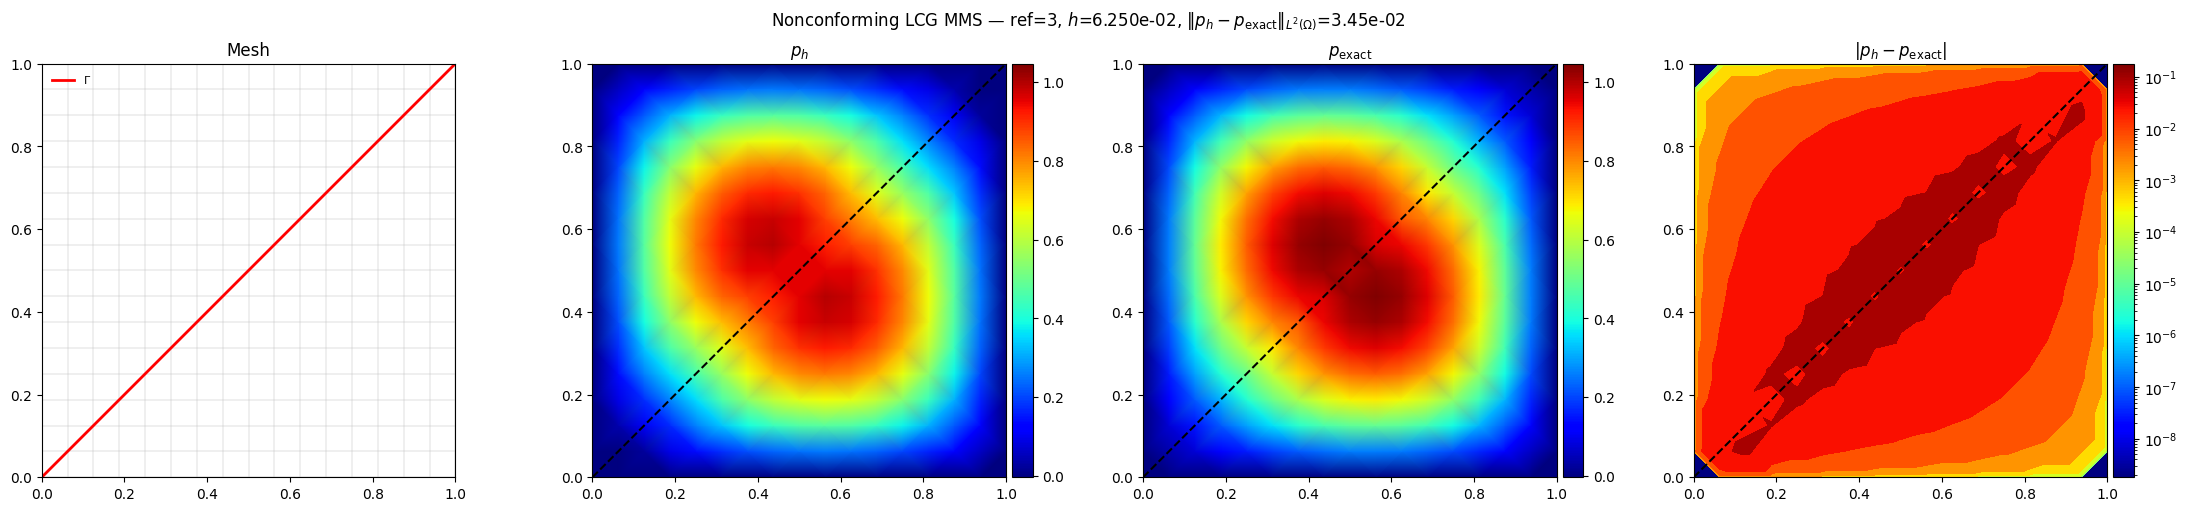


--- nonconforming LCG MMS convergence ref=4 ---
reading supplied bulk mesh Omega_ex1_4.msh
Info    : Reading 'Omega_ex1_4.msh'...
Info    : 27 entities
Info    : 2178 nodes
Info    : 1024 elements
Info    : Done reading 'Omega_ex1_4.msh'
reading cached fracture mesh for ref=4, h=3.125e-02
Info    : Reading 'fracture_problem_nonconforming/meshes/gamma_omega_ex1_ref4_h0p03125000_a0p000_0p000_b1p000_1p000_th0p020_flc0p500.msh'...
Info    : 3 entities
Info    : 92 nodes
Info    : 91 elements
Info    : Done reading 'fracture_problem_nonconforming/meshes/gamma_omega_ex1_ref4_h0p03125000_a0p000_0p000_b1p000_1p000_th0p020_flc0p500.msh'
h=3.125e-02, h_Gamma=h_lambda=1.554e-02, total dofs=2362, err_pm=1.152e-02, err_pf=1.227e-02, err_lambda_h_tip=6.570e+01


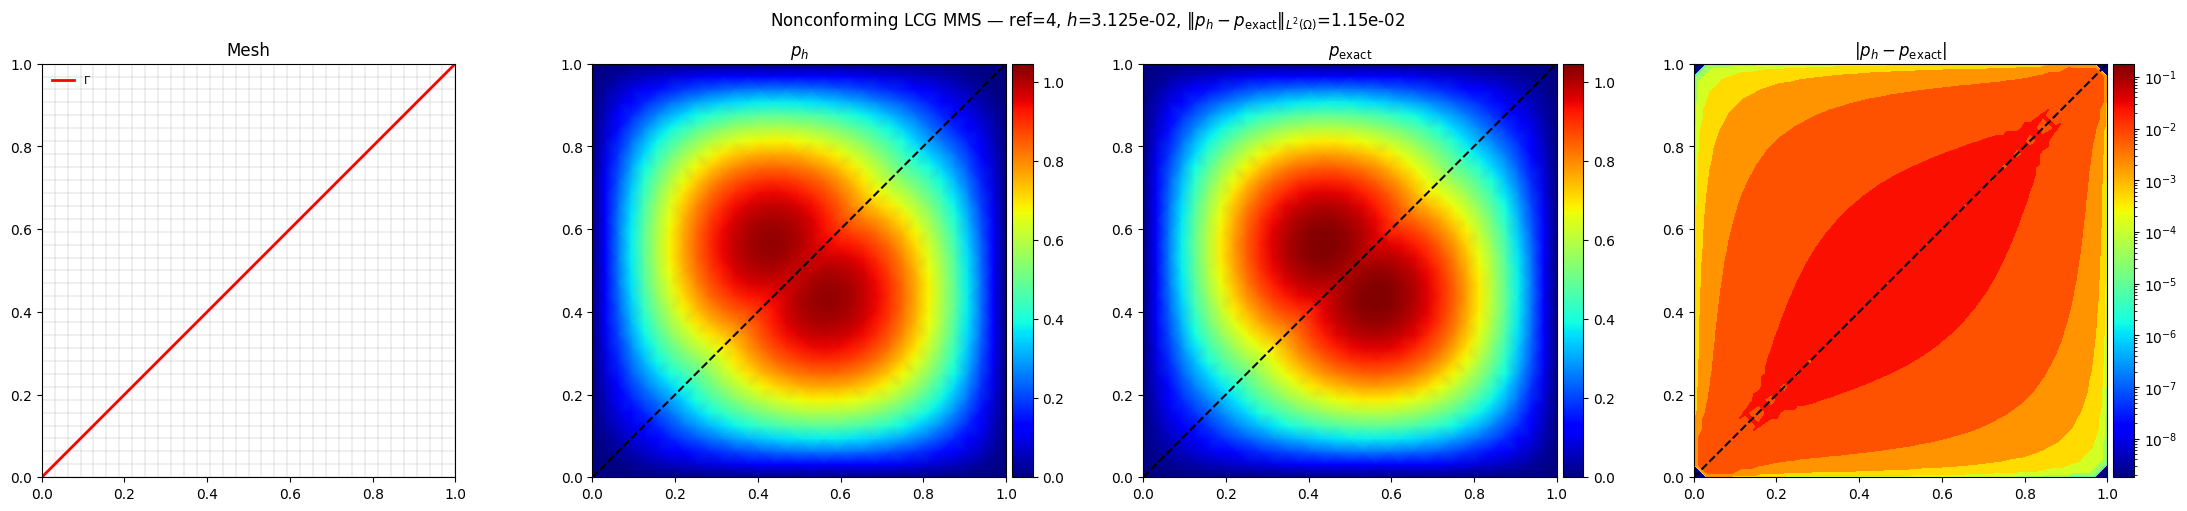


--- nonconforming LCG MMS convergence ref=5 ---
reading supplied bulk mesh Omega_ex1_5.msh
Info    : Reading 'Omega_ex1_5.msh'...
Info    : 27 entities
Info    : 8450 nodes
Info    : 4096 elements
Info    : Done reading 'Omega_ex1_5.msh'
reading cached fracture mesh for ref=5, h=1.562e-02
Info    : Reading 'fracture_problem_nonconforming/meshes/gamma_omega_ex1_ref5_h0p01562500_a0p000_0p000_b1p000_1p000_th0p020_flc0p500.msh'...
Info    : 3 entities
Info    : 183 nodes
Info    : 182 elements
Info    : Done reading 'fracture_problem_nonconforming/meshes/gamma_omega_ex1_ref5_h0p01562500_a0p000_0p000_b1p000_1p000_th0p020_flc0p500.msh'
h=1.562e-02, h_Gamma=h_lambda=7.770e-03, total dofs=8816, err_pm=4.329e-03, err_pf=3.170e-03, err_lambda_h_tip=4.009e+01


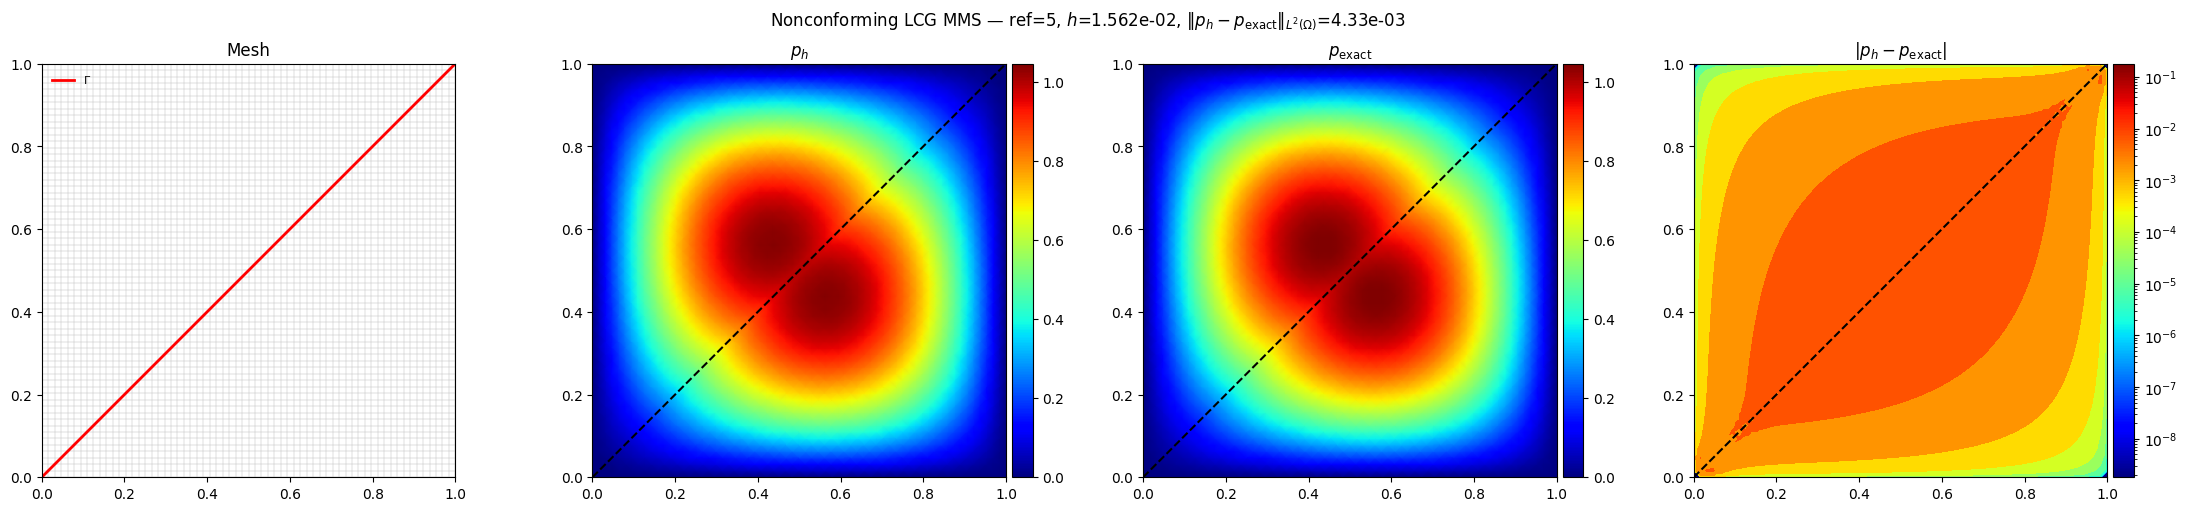


--- nonconforming LCG MMS convergence ref=6 ---
reading supplied bulk mesh Omega_ex1_6.msh
Info    : Reading 'Omega_ex1_6.msh'...
Info    : 27 entities
Info    : 33282 nodes
Info    : 16384 elements
Info    : Done reading 'Omega_ex1_6.msh'
reading cached fracture mesh for ref=6, h=7.812e-03
Info    : Reading 'fracture_problem_nonconforming/meshes/gamma_omega_ex1_ref6_h0p00781250_a0p000_0p000_b1p000_1p000_th0p020_flc0p500.msh'...
Info    : 3 entities
Info    : 364 nodes
Info    : 363 elements
Info    : Done reading 'fracture_problem_nonconforming/meshes/gamma_omega_ex1_ref6_h0p00781250_a0p000_0p000_b1p000_1p000_th0p020_flc0p500.msh'
h=7.812e-03, h_Gamma=h_lambda=3.896e-03, total dofs=34010, err_pm=1.834e-03, err_pf=7.996e-04, err_lambda_h_tip=2.841e+01


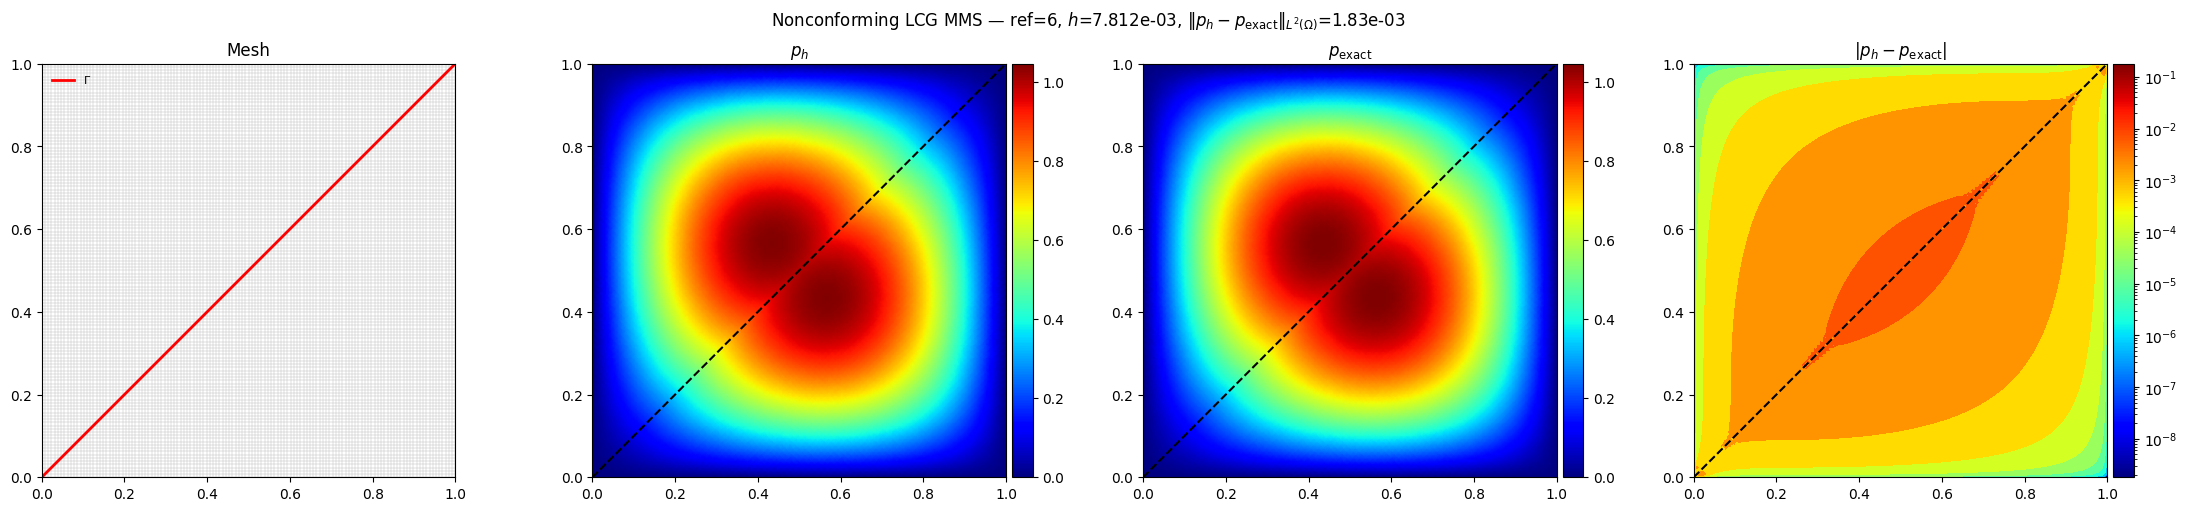


--- nonconforming LCG MMS convergence ref=7 ---
reading supplied bulk mesh Omega_ex1_7.msh
Info    : Reading 'Omega_ex1_7.msh'...
Info    : 27 entities
Info    : 132098 nodes
Info    : 65536 elements                                                                                      
Info    : Done reading 'Omega_ex1_7.msh'
reading cached fracture mesh for ref=7, h=3.906e-03
Info    : Reading 'fracture_problem_nonconforming/meshes/gamma_omega_ex1_ref7_h0p00390625_a0p000_0p000_b1p000_1p000_th0p020_flc0p500.msh'...
Info    : 3 entities
Info    : 726 nodes
Info    : 725 elements
Info    : Done reading 'fracture_problem_nonconforming/meshes/gamma_omega_ex1_ref7_h0p00390625_a0p000_0p000_b1p000_1p000_th0p020_flc0p500.msh'
h=3.906e-03, h_Gamma=h_lambda=1.951e-03, total dofs=133550, err_pm=8.347e-04, err_pf=1.931e-04, err_lambda_h_tip=2.398e+01


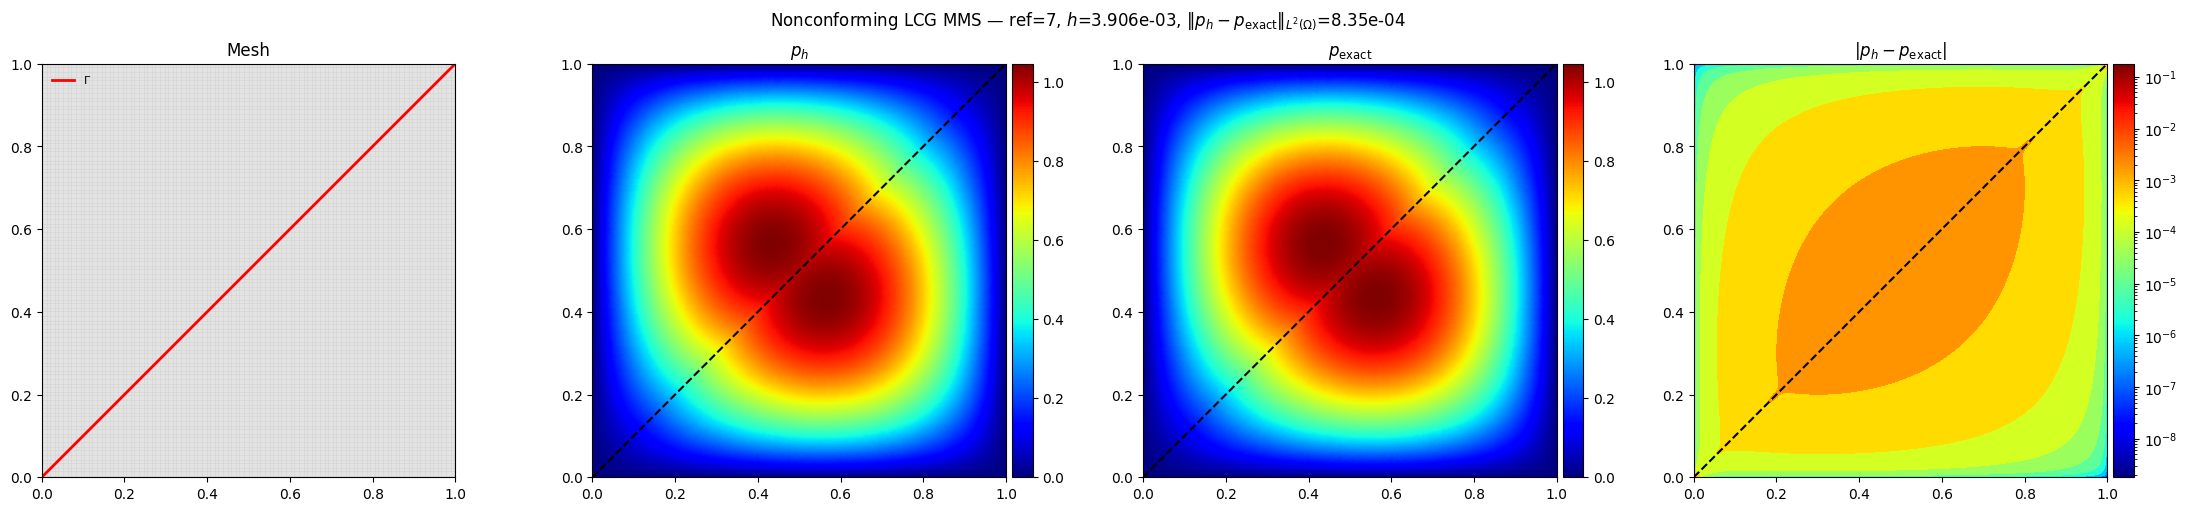


Convergence table
ref          h    h_G=h_l      dofs  it     ||p_h||     r     ||p_G||     r  ||lambda_h||tip     r   ||lambda_h||full
  2  1.250e-01  6.149e-02       210   1   1.164e-01   -     1.787e-01   -      2.087e+03   -      6.510e+04
  3  6.250e-02  3.074e-02       672   1   3.451e-02  1.75   4.875e-02  1.87    1.124e+02  4.21    4.962e+04
  4  3.125e-02  1.554e-02      2362   1   1.152e-02  1.58   1.227e-02  1.99    6.570e+01  0.78    4.005e+04
  5  1.562e-02  7.770e-03      8816   1   4.329e-03  1.41   3.170e-03  1.95    4.009e+01  0.71    2.910e+04
  6  7.812e-03  3.896e-03     34010   1   1.834e-03  1.24   7.996e-04  1.99    2.841e+01  0.50    2.090e+04
  7  3.906e-03  1.951e-03    133550   1   8.347e-04  1.14   1.931e-04  2.05    2.398e+01  0.24    1.481e+04


In [1]:
# Convergence analysis for the nonconforming LCG reference solve.
# The function definitions are reused below by the single-reference PINN run.
from mpi4py import MPI
import gmsh
import numpy as np
import ufl
import basix.ufl
from dolfinx import fem
from dolfinx.io import gmsh as gmshio
from fenicsx_ii import Average, Circle, LinearProblem
import matplotlib.tri as mtri
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm
from matplotlib.transforms import Bbox
import matplotlib as mpl
import pathlib

RUN_CONVERGENCE = False
CONV_REFS = list(range(2, 8))
CONV_TIP_FRAC = 0.1
TIP_FRAC = CONV_TIP_FRAC
FEM_ORDER = 1
CONV_PLOT = True

ALPHA = 1.0
K_M_VALUE = 1.0
K_F_VALUE = 100.0
SLAB_THICKNESS = 0.02
Z_FRACTURE = 0.5 * SLAB_THICKNESS

# Nonconforming fracture geometry: same full diagonal as the conforming MMS.
FRAC_A = np.array([0.0, 0.0], dtype=float)
FRAC_B = np.array([1.0, 1.0], dtype=float)
tau_np_global = (FRAC_B - FRAC_A) / np.linalg.norm(FRAC_B - FRAC_A)
normal_np_global = np.array([-tau_np_global[1], tau_np_global[0]], dtype=float)
L_GAMMA_GLOBAL = float(np.linalg.norm(FRAC_B - FRAC_A))
MESH_CACHE_DIR = pathlib.Path("fracture_problem_nonconforming") / "meshes"
USE_MESH_CACHE = True
OMEGA_MESH_DIR_CANDIDATES = [
    pathlib.Path("."),
    pathlib.Path("fenicsx/code/fracture problem"),
    pathlib.Path("fenicsx/code"),
]
# Martin/Koppel P1 multiplier choice: h_Gamma = h_lambda ~= h/2.
FRACTURE_LC_FACTOR = 0.5

def close_gmsh():
    try:
        if gmsh.isInitialized():
            gmsh.finalize()
    except Exception:
        pass

def omega_mesh_path(ref):
    name = f"Omega_ex1_{ref}.msh"
    for folder in OMEGA_MESH_DIR_CANDIDATES:
        path = folder / name
        if path.exists():
            return path
    searched = ", ".join(str(folder / name) for folder in OMEGA_MESH_DIR_CANDIDATES)
    raise FileNotFoundError(f"Could not find bulk mesh {name}. Searched: {searched}")

def estimate_bulk_h(mesh):
    coords = mesh.geometry.x

    def min_positive_spacing(values):
        vals = np.unique(np.round(np.sort(values), 14))
        diffs = np.diff(vals)
        diffs = diffs[diffs > 1.0e-12]
        return float(diffs.min()) if diffs.size else np.inf

    h_local = min(min_positive_spacing(coords[:, 0]), min_positive_spacing(coords[:, 1]))
    return float(mesh.comm.allreduce(h_local, op=MPI.MIN))

def gamma_cache_path(ref, h, fracture_lc_factor=FRACTURE_LC_FACTOR):
    tag = (
        f"omega_ex1_ref{ref}"
        f"_h{h:.8f}"
        f"_a{FRAC_A[0]:.3f}_{FRAC_A[1]:.3f}"
        f"_b{FRAC_B[0]:.3f}_{FRAC_B[1]:.3f}"
        f"_th{SLAB_THICKNESS:.3f}"
        f"_flc{fracture_lc_factor:.3f}"
    )
    tag = tag.replace("-", "m").replace(".", "p")
    return MESH_CACHE_DIR / f"gamma_{tag}.msh"

def make_nonconforming_meshes(ref, fracture_lc_factor=FRACTURE_LC_FACTOR):
    close_gmsh()
    comm = MPI.COMM_WORLD
    omega_file = omega_mesh_path(ref)
    if comm.rank == 0:
        print(f"reading supplied bulk mesh {omega_file}")
    omega = gmshio.read_from_msh(str(omega_file), comm, 0, gdim=3)[0]
    h = estimate_bulk_h(omega)
    gamma_file = gamma_cache_path(ref, h, fracture_lc_factor)

    if USE_MESH_CACHE:
        if comm.rank == 0:
            MESH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
        comm.barrier()
        if gamma_file.exists():
            if comm.rank == 0:
                print(f"reading cached fracture mesh for ref={ref}, h={h:.3e}")
            gamma = gmshio.read_from_msh(str(gamma_file), comm, 0, gdim=3)[0]
            return omega, gamma, h, fracture_lc_factor * h, fracture_lc_factor * h

    close_gmsh()
    gmsh.initialize()
    gmsh.model.add("Gamma_nonconforming_line")
    pa = gmsh.model.occ.addPoint(FRAC_A[0], FRAC_A[1], Z_FRACTURE)
    pb = gmsh.model.occ.addPoint(FRAC_B[0], FRAC_B[1], Z_FRACTURE)
    line = gmsh.model.occ.addLine(pa, pb)
    gmsh.model.occ.synchronize()
    gmsh.model.mesh.setSize([(0, pa), (0, pb)], fracture_lc_factor * h)
    pg = gmsh.model.addPhysicalGroup(1, [line])
    gmsh.model.setPhysicalName(1, pg, "Gamma")
    gmsh.model.mesh.generate(1)
    if USE_MESH_CACHE and comm.rank == 0:
        gmsh.write(str(gamma_file))
    gamma = gmshio.model_to_mesh(gmsh.model, comm, 0, gdim=3)[0]
    gmsh.finalize()
    if USE_MESH_CACHE:
        comm.barrier()
    return omega, gamma, h, fracture_lc_factor * h, fracture_lc_factor * h

def q_exact_xy(x0, y0):
    return np.sin(np.pi * x0) * np.sin(np.pi * y0)

def r_exact_xy(x0, y0):
    return normal_np_global[0] * (x0 - FRAC_A[0]) + normal_np_global[1] * (y0 - FRAC_A[1])

def p_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    return q + ALPHA * np.abs(r_exact_xy(x0, y0)) * q

def p_m_exact_fn(x):
    return p_m_exact_xy(x[0], x[1])

def p_gamma_exact_points(points):
    points = np.asarray(points, dtype=float)
    return q_exact_xy(points[:, 0], points[:, 1])

def p_gamma_exact_fn(x):
    return q_exact_xy(x[0], x[1])

def lambda_exact_points(points):
    return -2.0 * ALPHA * p_gamma_exact_points(points)

def lambda_exact_fn(x):
    return -2.0 * ALPHA * q_exact_xy(x[0], x[1])

def f_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    r = r_exact_xy(x0, y0)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    n_dot_grad_q = (
        normal_np_global[0] * np.pi * np.cos(np.pi * x0) * np.sin(np.pi * y0)
        + normal_np_global[1] * np.pi * np.sin(np.pi * x0) * np.cos(np.pi * y0)
    )
    return (
        2.0 * np.pi**2 * q
        + 2.0 * ALPHA * np.pi**2 * np.abs(r) * q
        - 2.0 * ALPHA * sign_r * n_dot_grad_q
    )

def f_m_exact_points(points):
    points = np.asarray(points, dtype=float)
    return f_m_exact_xy(points[:, 0], points[:, 1])

def f_gamma_exact_fn(x):
    qg = q_exact_xy(x[0], x[1])
    d2_q_ds2 = (
        -np.pi**2 * qg
        + 2.0 * np.pi**2 * tau_np_global[0] * tau_np_global[1]
          * np.cos(np.pi * x[0]) * np.cos(np.pi * x[1])
    )
    return -K_F_VALUE * d2_q_ds2 + lambda_exact_fn(x)

def s_coord_points(points):
    points = np.asarray(points, dtype=float)
    return (points[:, :2] - FRAC_A[None, :]) @ tau_np_global

def projected_dof_values(V, values):
    coords = V.tabulate_dof_coordinates()
    xy = coords[:, :2]
    keys, inv = np.unique(np.round(xy, 12), axis=0, return_inverse=True)
    vals = np.zeros(len(keys), dtype=float)
    counts = np.zeros(len(keys), dtype=float)
    np.add.at(vals, inv, values)
    np.add.at(counts, inv, 1.0)
    vals /= np.maximum(counts, 1.0)
    return keys, vals

def structured_grid_from_projected_values(coords, values):
    coords = np.round(np.asarray(coords, dtype=float), 12)
    values = np.asarray(values, dtype=float)
    xs = np.unique(coords[:, 0])
    ys = np.unique(coords[:, 1])
    if xs.size * ys.size != coords.shape[0]:
        return None
    X, Y = np.meshgrid(xs, ys)
    Z = np.full_like(X, np.nan, dtype=float)
    x_index = {x: i for i, x in enumerate(xs)}
    y_index = {y: j for j, y in enumerate(ys)}
    for (xv, yv), val in zip(coords, values):
        Z[y_index[xv], x_index[xv]] = val
    if np.isnan(Z).any():
        return None
    return X, Y, Z

def projected_cell_edge_segments(mesh):
    tdim = mesh.topology.dim
    mesh.topology.create_connectivity(tdim, 0)
    c2v = mesh.topology.connectivity(tdim, 0)
    num_cells = mesh.topology.index_map(tdim).size_local
    segments = []
    seen = set()

    for cell in range(num_cells):
        verts = np.asarray(c2v.links(cell), dtype=np.int32)
        xy = mesh.geometry.x[verts, :2]
        xy = np.unique(np.round(xy, 12), axis=0)
        if xy.shape[0] < 2:
            continue
        if xy.shape[0] > 2:
            ctr = xy.mean(axis=0)
            order = np.argsort(np.arctan2(xy[:, 1] - ctr[1], xy[:, 0] - ctr[0]))
            xy = xy[order]
        for i in range(xy.shape[0]):
            a = tuple(xy[i])
            b = tuple(xy[(i + 1) % xy.shape[0]])
            key = tuple(sorted((a, b)))
            if key not in seen:
                seen.add(key)
                segments.append([a, b])
    return np.asarray(segments, dtype=float)

def solve_lcg_nonconforming_mms(ref, tip_frac=CONV_TIP_FRAC, return_solution=False, verbose=False):
    omega, gamma, h, h_gamma_target, h_lambda_target = make_nonconforming_meshes(ref)
    comm = omega.comm
    order = FEM_ORDER
    V_m = fem.functionspace(omega, ("Lagrange", order))
    V_f = fem.functionspace(gamma, ("Lagrange", order))
    V_l = fem.functionspace(gamma, ("Lagrange", order))
    W = ufl.MixedFunctionSpace(V_m, V_f, V_l)
    phi, psi, mu = ufl.TestFunctions(W)
    p_m_trial, p_f_trial, lmbd_trial = ufl.TrialFunctions(W)

    x = ufl.SpatialCoordinate(omega)
    q = ufl.sin(np.pi * x[0]) * ufl.sin(np.pi * x[1])
    r = normal_np_global[0] * (x[0] - FRAC_A[0]) + normal_np_global[1] * (x[1] - FRAC_A[1])
    abs_r = ufl.conditional(ufl.ge(r, 0.0), r, -r)
    sign_r = ufl.conditional(ufl.ge(r, 0.0), 1.0, -1.0)
    n_dot_grad_q = (
        normal_np_global[0] * np.pi * ufl.cos(np.pi * x[0]) * ufl.sin(np.pi * x[1])
        + normal_np_global[1] * np.pi * ufl.sin(np.pi * x[0]) * ufl.cos(np.pi * x[1])
    )
    f_m_ufl = (
        2.0 * np.pi**2 * q
        + 2.0 * ALPHA * np.pi**2 * abs_r * q
        - 2.0 * ALPHA * sign_r * n_dot_grad_q
    )

    xg = ufl.SpatialCoordinate(gamma)
    qg = ufl.sin(np.pi * xg[0]) * ufl.sin(np.pi * xg[1])
    d2_q_ds2 = (
        -np.pi**2 * qg
        + 2.0 * np.pi**2 * tau_np_global[0] * tau_np_global[1]
          * ufl.cos(np.pi * xg[0]) * ufl.cos(np.pi * xg[1])
    )
    lam_g = -2.0 * ALPHA * qg
    f_f_ufl = -K_F_VALUE * d2_q_ds2 + lam_g

    # The 3D slab integral is divided by thickness to reproduce the 2D weak form.
    K_solve = fem.Constant(
        omega,
        np.array(
            [[K_M_VALUE / SLAB_THICKNESS, 0.0, 0.0],
             [0.0, K_M_VALUE / SLAB_THICKNESS, 0.0],
             [0.0, 0.0, 0.0]],
            dtype=np.float64,
        ),
    )
    k_m = fem.Constant(omega, K_M_VALUE)
    k_f = fem.Constant(gamma, K_F_VALUE)
    dx = ufl.Measure("dx", domain=omega)
    dx_f = ufl.Measure("dx", domain=gamma)

    R_circle = min(0.49 * SLAB_THICKNESS, 0.25 * h)

    def circle_radius_on_gamma(x):
        # The full diagonal has boundary tips.  A constant circle radius would
        # sample outside the slab near those tips, so shrink the circle there.
        s = tau_np_global[0] * (x[0] - FRAC_A[0]) + tau_np_global[1] * (x[1] - FRAC_A[1])
        tip_dist = np.minimum(s, L_GAMMA_GLOBAL - s)
        return np.maximum(0.0, np.minimum(R_circle, 0.49 * tip_dist))

    q_degree = 12
    restriction_trial = Circle(gamma, circle_radius_on_gamma, degree=q_degree)
    restriction_test = Circle(gamma, circle_radius_on_gamma, degree=q_degree)
    q_el = basix.ufl.quadrature_element(gamma.basix_cell(), value_shape=(), degree=q_degree)
    Rs = fem.functionspace(gamma, q_el)
    avg_pm = Average(p_m_trial, restriction_trial, Rs)
    avg_phi = Average(phi, restriction_test, Rs)

    a = (
        ufl.inner(K_solve * ufl.grad(p_m_trial), ufl.grad(phi)) * dx
        - lmbd_trial * avg_phi * dx_f
        + ufl.inner(k_f * ufl.grad(p_f_trial), ufl.grad(psi)) * dx_f
        + lmbd_trial * psi * dx_f
        + avg_pm * mu * dx_f
        - p_f_trial * mu * dx_f
    )
    L = (f_m_ufl / SLAB_THICKNESS) * phi * dx + f_f_ufl * psi * dx_f + fem.Constant(gamma, 0.0) * mu * dx_f

    tol = 1e-10
    bdofs = fem.locate_dofs_geometrical(
        V_m,
        lambda x: (
            np.isclose(x[0], 0.0, atol=tol)
            | np.isclose(x[0], 1.0, atol=tol)
            | np.isclose(x[1], 0.0, atol=tol)
            | np.isclose(x[1], 1.0, atol=tol)
        ),
    )
    pbc = fem.Function(V_m)
    pbc.interpolate(p_m_exact_fn)
    bc_pm = fem.dirichletbc(pbc, bdofs)

    tip_dofs = fem.locate_dofs_geometrical(
        V_f,
        lambda x: (
            (np.isclose(x[0], FRAC_A[0], atol=tol) & np.isclose(x[1], FRAC_A[1], atol=tol))
            | (np.isclose(x[0], FRAC_B[0], atol=tol) & np.isclose(x[1], FRAC_B[1], atol=tol))
        ),
    )
    pfbc = fem.Function(V_f)
    pfbc.interpolate(p_gamma_exact_fn)
    bc_pf = fem.dirichletbc(pfbc, tip_dofs)

    petsc_options = {
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
        "mat_mumps_icntl_14": 120,
        "ksp_error_if_not_converged": True,
    }
    if verbose:
        petsc_options["ksp_monitor"] = None
    problem = LinearProblem(
        a,
        L,
        bcs=[bc_pm, bc_pf],
        petsc_options_prefix=f"nonconf_mms_ref{ref}_",
        petsc_options=petsc_options,
    )
    p_m, p_f, lmbd = problem.solve()

    # Interpolated exact fields are kept for plotting and later diagnostics only.
    # The reported convergence errors below are integrated against analytic MMS
    # expressions at quadrature points, not against FE interpolants.
    p_m_ex = fem.Function(V_m, name="p_m_exact")
    p_m_ex.interpolate(p_m_exact_fn)
    p_f_ex = fem.Function(V_f, name="p_gamma_exact")
    p_f_ex.interpolate(p_gamma_exact_fn)
    lam_ex = fem.Function(V_l, name="lambda_exact")
    lam_ex.interpolate(lambda_exact_fn)

    err_quad_degree = max(8, 2 * order + 6)
    dx_err = ufl.Measure("dx", domain=omega, metadata={"quadrature_degree": err_quad_degree})
    dx_f_err = ufl.Measure("dx", domain=gamma, metadata={"quadrature_degree": err_quad_degree})
    p_m_exact_ufl = q + ALPHA * abs_r * q
    p_f_exact_ufl = qg
    lam_exact_ufl = lam_g

    def sqrt_global(expr, divisor=1.0):
        local = fem.assemble_scalar(fem.form(expr))
        total = comm.allreduce(local, op=MPI.SUM)
        return np.sqrt(max(total / divisor, 0.0))

    err_pm = sqrt_global((p_m - p_m_exact_ufl) ** 2 * dx_err, divisor=SLAB_THICKNESS)
    err_pf = sqrt_global((p_f - p_f_exact_ufl) ** 2 * dx_f_err)
    err_lam = sqrt_global((lmbd - lam_exact_ufl) ** 2 * dx_f_err)

    s_ufl = tau_np_global[0] * (xg[0] - FRAC_A[0]) + tau_np_global[1] * (xg[1] - FRAC_A[1])
    t_ufl = s_ufl / L_GAMMA_GLOBAL
    interior = ufl.conditional(
        ufl.ge(t_ufl, tip_frac),
        ufl.conditional(ufl.le(t_ufl, 1.0 - tip_frac), 1.0, 0.0),
        0.0,
    )
    err_lam_int = sqrt_global(interior * (lmbd - lam_exact_ufl) ** 2 * dx_f_err)

    # Same fracture mesh is used for p_Gamma,h and lambda_h.
    h_gamma = L_GAMMA_GLOBAL / max(gamma.topology.index_map(gamma.topology.dim).size_global, 1)
    h_lambda = h_gamma

    ndof_pm = V_m.dofmap.index_map.size_global
    ndof_pf = V_f.dofmap.index_map.size_global
    ndof_lam = V_l.dofmap.index_map.size_global

    coords_plot = pm_plot = pm_ex_plot = mesh_edges_plot = None
    if CONV_PLOT:
        coords_plot, pm_plot = projected_dof_values(V_m, p_m.x.array.copy())
        _, pm_ex_plot = projected_dof_values(V_m, p_m_ex.x.array.copy())
        mesh_edges_plot = projected_cell_edge_segments(omega)

    row = {
        "ref": ref,
        "h": h,
        "h_gamma": h_gamma,
        "h_lambda": h_lambda,
        "h_gamma_target": h_gamma_target,
        "h_lambda_target": h_lambda_target,
        "ndof_pm": ndof_pm,
        "ndof_pf": ndof_pf,
        "ndof_lam": ndof_lam,
        "ndof_total": ndof_pm + ndof_pf + ndof_lam,
        "iterations": 1,
        "order": order,
        "err_pm": err_pm,
        "err_pf": err_pf,
        "err_lam": err_lam,
        "err_lam_int": err_lam_int,
        "plot_dof_coords": coords_plot,
        "plot_triangles": None,
        "plot_mesh_edges": mesh_edges_plot,
        "plot_pm": pm_plot,
        "plot_pm_ex": pm_ex_plot,
    }
    if return_solution:
        row.update(
            {
                "omega": omega,
                "gamma": gamma,
                "V_m": V_m,
                "V_f": V_f,
                "V_l": V_l,
                "p_m": p_m,
                "p_f": p_f,
                "lmbd": lmbd,
                "p_m_ex": p_m_ex,
                "p_f_ex": p_f_ex,
                "lam_ex": lam_ex,
                "dx": dx,
                "dx_f": dx_f,
                "k_m": k_m,
                "k_f": k_f,
                "K_solve": K_solve,
                "R_circle": R_circle,
                "h_gamma": h_gamma,
                "h_lambda": h_lambda,
                "h_gamma_target": h_gamma_target,
                "h_lambda_target": h_lambda_target,
                "order": order,
            }
        )
    return row

def add_rates(rows):
    for i, row in enumerate(rows):
        for key in ("err_pm", "err_pf", "err_lam_int"):
            row[f"rate_{key}"] = np.nan
            if i > 0 and row[key] > 0 and rows[i - 1][key] > 0:
                row[f"rate_{key}"] = np.log(rows[i - 1][key] / row[key]) / np.log(rows[i - 1]["h"] / row["h"])
    return rows

def fmt_rate(value):
    return "  -  " if not np.isfinite(value) else f"{value:5.2f}"

conv_results = []
err_vmax = None
if RUN_CONVERGENCE:
    for ref in CONV_REFS:
        if MPI.COMM_WORLD.rank == 0:
            print(f"\n--- nonconforming LCG MMS convergence ref={ref} ---")
        conv_results.append(solve_lcg_nonconforming_mms(ref, tip_frac=CONV_TIP_FRAC, return_solution=False))
        add_rates(conv_results)
        row = conv_results[-1]
        if MPI.COMM_WORLD.rank == 0:
            print(
                f"h={row['h']:.3e}, h_Gamma=h_lambda={row['h_gamma']:.3e}, total dofs={row['ndof_total']}, "
                f"err_pm={row['err_pm']:.3e}, err_pf={row['err_pf']:.3e}, "
                f"err_lambda_h_tip={row['err_lam_int']:.3e}"
            )

        if CONV_PLOT and MPI.COMM_WORLD.rank == 0:
            coords = row["plot_dof_coords"]
            mesh_edges = row.get("plot_mesh_edges")
            pm_vals = row["plot_pm"]
            pm_ex_v = row["plot_pm_ex"]
            diff = np.abs(pm_vals - pm_ex_v)
            if err_vmax is None:
                err_vmax = float(max(diff.max(), 1e-14))

            tri_obj = mtri.Triangulation(coords[:, 0], coords[:, 1])
            vmin_p = float(min(pm_vals.min(), pm_ex_v.min()))
            vmax_p = float(max(pm_vals.max(), pm_ex_v.max()))
            err_floor = max(err_vmax * 1e-8, np.finfo(float).tiny)
            diff_plot = np.maximum(diff, err_floor)
            grid_pm = structured_grid_from_projected_values(coords, pm_vals)
            grid_pm_ex = structured_grid_from_projected_values(coords, pm_ex_v)
            grid_diff = structured_grid_from_projected_values(coords, diff_plot)
            err_levels = np.logspace(np.log10(err_floor), np.log10(err_vmax), 15)
            norm_err = LogNorm(vmin=err_floor, vmax=err_vmax)

            def _attach_cbar(fig, ax, mappable, label=""):
                div = make_axes_locatable(ax)
                cax = div.append_axes("right", size="5%", pad=0.06)
                fig.colorbar(mappable, cax=cax, label=label)

            fig, axes = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)
            fig.suptitle(
                fr"Nonconforming LCG MMS — ref={row['ref']}, $h$={row['h']:.3e}, "
                fr"$\|p_h-p_{{\rm exact}}\|_{{L^2(\Omega)}}$={row['err_pm']:.2e}",
                fontsize=12,
            )

            if mesh_edges is not None and len(mesh_edges):
                axes[0].add_collection(LineCollection(mesh_edges, colors="0.75", linewidths=0.35))
            else:
                axes[0].triplot(tri_obj, lw=0.3, color="0.55")
            axes[0].plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "r-", lw=2, label=r"$\Gamma$")
            axes[0].set_aspect("equal"); axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
            axes[0].set_title("Mesh")
            axes[0].legend(fontsize=8, loc="upper left", frameon=False)
            div0 = make_axes_locatable(axes[0])
            cax0 = div0.append_axes("right", size="5%", pad=0.06)
            cax0.axis("off")

            if grid_pm is not None:
                im1 = axes[1].pcolormesh(*grid_pm, shading="gouraud", vmin=vmin_p, vmax=vmax_p, cmap="jet")
            else:
                im1 = axes[1].tripcolor(tri_obj, pm_vals, shading="gouraud", vmin=vmin_p, vmax=vmax_p, cmap="jet")
            axes[1].plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k--", lw=1.5)
            axes[1].set_aspect("equal"); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
            axes[1].set_title(r"$p_h$")
            _attach_cbar(fig, axes[1], im1)

            if grid_pm_ex is not None:
                im2 = axes[2].pcolormesh(*grid_pm_ex, shading="gouraud", vmin=vmin_p, vmax=vmax_p, cmap="jet")
            else:
                im2 = axes[2].tripcolor(tri_obj, pm_ex_v, shading="gouraud", vmin=vmin_p, vmax=vmax_p, cmap="jet")
            axes[2].plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k--", lw=1.5)
            axes[2].set_aspect("equal"); axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1)
            axes[2].set_title(r"$p_{\rm exact}$")
            _attach_cbar(fig, axes[2], im2)

            if grid_diff is not None:
                im3 = axes[3].pcolormesh(*grid_diff, shading="gouraud", norm=norm_err, cmap="jet")
            else:
                im3 = axes[3].tricontourf(tri_obj, diff_plot, levels=err_levels, norm=norm_err, cmap="jet", extend="min")
            axes[3].plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k--", lw=1.5)
            axes[3].set_aspect("equal"); axes[3].set_xlim(0, 1); axes[3].set_ylim(0, 1)
            axes[3].set_title(r"$|p_h - p_{\rm exact}|$")
            sm3 = mpl.cm.ScalarMappable(cmap="jet", norm=norm_err)
            sm3.set_array([])
            _attach_cbar(fig, axes[3], sm3)

            out_dir = pathlib.Path("fracture_problem_nonconforming")
            out_dir.mkdir(parents=True, exist_ok=True)
            fig.canvas.draw()
            renderer = fig.canvas.get_renderer()

            def _crop(axs):
                bbs = [ax.get_tightbbox(renderer) for ax in axs]
                return Bbox.union([b for b in bbs if b is not None]).transformed(fig.dpi_scale_trans.inverted())

            ref_tag = row["ref"]
            fig.savefig(out_dir / f"nonconf_lcg_mms_ref{ref_tag}_mesh.png", bbox_inches=_crop([axes[0]]), dpi=200)
            fig.savefig(out_dir / f"nonconf_lcg_mms_ref{ref_tag}_ph.png", bbox_inches=_crop([axes[1], fig.axes[5]]), dpi=200)
            fig.savefig(out_dir / f"nonconf_lcg_mms_ref{ref_tag}_error.png", bbox_inches=_crop([axes[3], fig.axes[7]]), dpi=200)
            plt.show()
            plt.close(fig)

if RUN_CONVERGENCE and MPI.COMM_WORLD.rank == 0:
    print("\nConvergence table")
    print(
        f"{'ref':>3} {'h':>10} {'h_G=h_l':>10} {'dofs':>9} {'it':>3} "
        f"{'||p_h||':>11} {'r':>5} {'||p_G||':>11} {'r':>5} "
        f"{'||lambda_h||tip':>16} {'r':>5} {'||lambda_h||full':>18}"
    )
    for row in conv_results:
        print(
            f"{row['ref']:3d} {row['h']:10.3e} {row['h_gamma']:10.3e} {row['ndof_total']:9d} {row['iterations']:3d} "
            f"{row['err_pm']:11.3e} {fmt_rate(row['rate_err_pm']):>5} "
            f"{row['err_pf']:11.3e} {fmt_rate(row['rate_err_pf']):>5} "
            f"{row['err_lam_int']:12.3e} {fmt_rate(row['rate_err_lam_int']):>5} "
            f"{row['err_lam']:12.3e}"
        )


Convergence plot warning: refs not available in conv_results: [8]
Convergence plot refs: [3, 4, 5, 6, 7]


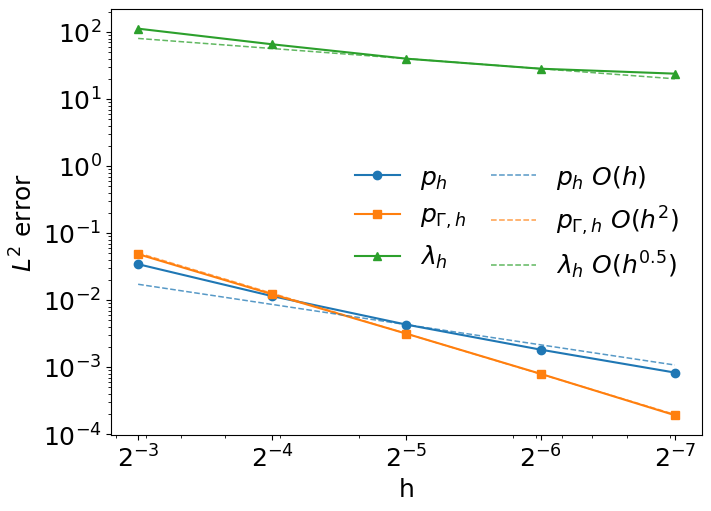

In [2]:
if CONV_PLOT and len(conv_results):
    try:
        import matplotlib.pyplot as plt

        # Select refinements to include in the convergence plot.
        # Use None, "all", or [] for every computed refinement; e.g. [5, 6, 7, 8].
        # CONV_PLOT_REFS = None
        CONV_PLOT_REFS = [3,4,5,6,7,8]

        # Dashed benchmark-line orders for each plotted quantity.
        CONV_BENCHMARK_ORDERS = {
            "p": 1.0,
            "p_Gamma": 2,
            "lambda": 0.5,
        }

        # Select the refinement where the benchmark lines are anchored.
        # Use None for the coarsest plotted refinement, one int for all lines,
        # or a dict such as {"p": 5, "p_Gamma": 5, "lambda": 6}.
        CONV_BENCHMARK_ANCHOR_REF = {"p": 5, "p_Gamma": 5, "lambda": 6}

        def selected_convergence_rows(rows, selected_refs):
            if selected_refs is None:
                return list(rows)
            if isinstance(selected_refs, str):
                if selected_refs.lower() == "all":
                    return list(rows)
                requested = [int(ref.strip()) for ref in selected_refs.split(",") if ref.strip()]
            elif isinstance(selected_refs, (int, np.integer)):
                requested = [int(selected_refs)]
            else:
                requested = [int(ref) for ref in selected_refs]
            if not requested:
                return list(rows)

            available = {int(row["ref"]) for row in rows}
            missing = [ref for ref in requested if ref not in available]
            if missing:
                print(f"Convergence plot warning: refs not available in conv_results: {missing}")
            requested_set = set(requested)
            return [row for row in rows if int(row["ref"]) in requested_set]

        def benchmark_label(order):
            order = float(order)
            if np.isclose(order, 1.0):
                return r"$O(h)$"
            if np.isclose(order, round(order)):
                return rf"$O(h^{int(round(order))})$"
            return rf"$O(h^{{{order:g}}})$"

        def benchmark_anchor_ref(anchor_refs, series_name):
            if isinstance(anchor_refs, dict):
                return anchor_refs.get(series_name, anchor_refs.get("default", None))
            return anchor_refs

        def add_benchmark_line(ax, refs, hs, values, order, h_span=None, anchor_ref=None, legend_label=None, color="black"):
            mask = np.isfinite(hs) & np.isfinite(values) & (hs > 0.0) & (values > 0.0)
            if np.count_nonzero(mask) < 1:
                return False
            refs_valid = refs[mask]
            h_valid = hs[mask]
            v_valid = values[mask]
            anchor = np.argmax(h_valid)
            if anchor_ref is not None:
                anchor_matches = np.flatnonzero(refs_valid == int(anchor_ref))
                if anchor_matches.size:
                    anchor = int(anchor_matches[0])
                else:
                    print(f"Benchmark anchor ref={anchor_ref} is not plotted; using coarsest plotted ref.")
            h0 = h_valid[anchor]
            v0 = v_valid[anchor]
            if np.count_nonzero(mask) >= 2:
                h_ref = np.array([h_valid.max(), h_valid.min()])
            elif h_span is not None:
                h_span = np.asarray(h_span, dtype=float)
                h_span = h_span[np.isfinite(h_span) & (h_span > 0.0)]
                h_ref = np.array([h_span.max(), h_span.min()]) if h_span.size >= 2 else h0 * np.array([2.0, 0.5])
            else:
                h_ref = h0 * np.array([2.0, 0.5])
            v_ref = v0 * (h_ref / h0)**float(order)
            ax.loglog(
                h_ref, v_ref, "--", color=color, lw=1.1, alpha=0.75,
                label=legend_label if legend_label is not None else "_nolegend_",
            )
            return True

        plot_rows = selected_convergence_rows(conv_results, CONV_PLOT_REFS)
        if not plot_rows:
            raise ValueError("No convergence rows selected. Check CONV_PLOT_REFS.")

        refs = np.array([row["ref"] for row in plot_rows], dtype=int)
        hs = np.array([row["h"] for row in plot_rows], dtype=float)
        all_hs = np.array([row["h"] for row in conv_results], dtype=float)
        plot_series = [
            ("p", "err_pm", r"$p_h$", "o-"),
            ("p_Gamma", "err_pf", r"$p_{\Gamma,h}$", "s-"),
            ("lambda", "err_lam_int", r"$\lambda_h$", "^-"),
        ]

        fs = 18
        fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
        plotted = []
        for name, err_key, label, style in plot_series:
            values = np.array([row[err_key] for row in plot_rows], dtype=float)
            line, = ax.loglog(hs, values, style, label=label)
            plotted.append((name, label, values, line.get_color()))

        for name, label, values, color in plotted:
            order = CONV_BENCHMARK_ORDERS.get(name, 2.0)
            anchor_ref = benchmark_anchor_ref(CONV_BENCHMARK_ANCHOR_REF, name)
            legend_label = rf"{label} {benchmark_label(order)}"
            add_benchmark_line(ax, refs, hs, values, order, h_span=all_hs, anchor_ref=anchor_ref, legend_label=legend_label, color=color)

        selected_refs = [int(row["ref"]) for row in plot_rows]
        print(f"Convergence plot refs: {selected_refs}")
        ax.invert_xaxis()
        ax.set_xticks(hs)
        ax.set_xticklabels([rf"$2^{{-{ref}}}$" for ref in refs])
        ax.set_xlabel("h", fontsize=fs)
        ax.set_ylabel(r"$L^2$ error", fontsize=fs)
        ax.tick_params(axis="both", which="both", labelsize=fs)
        # ax.set_title("LCG MMS convergence")
        ax.grid(False)
        ax.legend(frameon=False, fontsize=fs, ncol=2, columnspacing=1.0, handlelength=1.8)
        plt.show()
    except Exception as exc:
        print(f"Convergence plot skipped: {exc}")


## 1. LCG reference solve

Run this notebook in the same directory as the `.msh` files, or update `filename` below.


In [ ]:
from mpi4py import MPI
import numpy as np
from scipy.spatial import cKDTree
from dolfinx import fem
import ufl

# Single reference level used by the PINN reconstruction cells below.
N_ref = 5
ref = N_ref

sol = solve_lcg_nonconforming_mms(ref, tip_frac=CONV_TIP_FRAC, return_solution=True, verbose=False)
globals().update(sol)

lc = h
x_start, y_start = FRAC_A
x_end, y_end = FRAC_B
Lx, Ly = 1.0, 1.0
FRACTURE_LC_FACTOR = 0.5

print(f"nonconforming reference solve: ref={ref}, P{order}, h={h:.3e}")
print(f"  h_Gamma = h_lambda = {h_gamma:.3e} (target {h_gamma_target:.3e})")
print(f"  R_circle={R_circle:.3e}, slab thickness={SLAB_THICKNESS:.3e}")
print(f"  ||p_h-p||_L2(projected) = {err_pm:.3e}")
print(f"  ||p_Gamma,h-p_Gamma||_L2 = {err_pf:.3e}")
print(f"  ||lambda_h-lambda||_L2 full = {err_lam:.3e}")
print(f"  ||lambda_h-lambda||_L2 excl. {CONV_TIP_FRAC*100:.0f}% tips = {err_lam_int:.3e}")


In [ ]:
# ── MMS verification: compare FEM solution to exact ──────────────────
import numpy as np

# TIP_FRAC = CONV_TIP_FRAC
TIP_FRAC = 0.1

err_pm = fem.assemble_scalar(fem.form((p_m - p_m_ex) ** 2 * dx))
print(f'||p_m - p_m_ex||_L2(projected) = {np.sqrt(err_pm / SLAB_THICKNESS):.4e}')

err_pf = fem.assemble_scalar(fem.form((p_f - p_f_ex) ** 2 * dx_f))
print(f'||p_Gamma - p_Gamma_ex||_L2 = {np.sqrt(err_pf):.4e}')

err_lam = fem.assemble_scalar(fem.form((lmbd - lam_ex) ** 2 * dx_f))
print(f'||lambda_h - lambda||_L2 (full) = {np.sqrt(err_lam):.4e}')

xg = ufl.SpatialCoordinate(gamma)
s_gamma = tau_np_global[0] * (xg[0] - FRAC_A[0]) + tau_np_global[1] * (xg[1] - FRAC_A[1])
t_gamma = s_gamma / L_GAMMA_GLOBAL
interior = ufl.conditional(
    ufl.ge(t_gamma, TIP_FRAC),
    ufl.conditional(ufl.le(t_gamma, 1.0 - TIP_FRAC), 1.0, 0.0),
    0.0,
)
err_lam_int = fem.assemble_scalar(fem.form(interior * (lmbd - lam_ex) ** 2 * dx_f))
print(f'||lambda_h - lambda||_L2 (excl. {TIP_FRAC*100:.0f}% tips) = {np.sqrt(err_lam_int):.4e}')


## 2. Mesh, fracture, and CG flux utilities


In [5]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm import tqdm
from dolfinx import geometry

torch.set_default_dtype(torch.float32)
SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tdim = omega.topology.dim
gdim = omega.geometry.dim
omega_geometry_3d = omega.geometry.x
omega_geometry = omega.geometry.x[:, :2]

omega.topology.create_connectivity(tdim, 0)
c2v = omega.topology.connectivity(tdim, 0)
num_cells = omega.topology.index_map(tdim).size_local
local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]

def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)

def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0:
        poly = poly[::-1]
    return poly

def unique_projected_points(pts, decimals=12):
    pts = np.asarray(pts, dtype=float)[:, :2]
    _, idx = np.unique(np.round(pts, decimals), axis=0, return_index=True)
    return pts[np.sort(idx)]

cell_polys = []
for verts in local_cell_vertices:
    poly_pts = unique_projected_points(omega_geometry[verts])
    cell_polys.append(order_polygon_vertices(poly_pts))

cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])
h_est = float(np.sqrt(np.mean(cell_areas)))
xmin, ymin = omega_geometry.min(axis=0)
xmax, ymax = omega_geometry.max(axis=0)
print("num projected cells:", num_cells, "h_est:", h_est)

def edge_key(x0, x1, decimals=12):
    a = tuple(np.round(x0, decimals))
    b = tuple(np.round(x1, decimals))
    return tuple(sorted((a, b)))

shadow_edges = []
seen_edges = set()
for poly in cell_polys:
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        key = edge_key(x0, x1)
        if key not in seen_edges:
            seen_edges.add(key)
            shadow_edges.append((x0.copy(), x1.copy()))
print("unique projected mesh edges:", len(shadow_edges))

# Build the physical Darcy flux q_cg = -K_m grad(p_m), not the scaled slab operator.
Wq = fem.functionspace(omega, ("DG", order, (gdim,)))
q_cg_expr = fem.Expression(-k_m * ufl.grad(p_m), Wq.element.interpolation_points)
q_cg_fun = fem.Function(Wq, name="q_cg")
q_cg_fun.interpolate(q_cg_expr)

def as_3d_points(points, z_value=Z_FRACTURE):
    points = np.asarray(points, dtype=float)
    if points.ndim == 1:
        points = points.reshape(1, -1)
    if points.shape[1] == 3:
        return points.copy()
    pts3 = np.zeros((points.shape[0], 3), dtype=float)
    pts3[:, :2] = points[:, :2]
    pts3[:, 2] = z_value
    return pts3

def eval_fem_function(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    pts3 = as_3d_points(points)
    tree = geometry.bb_tree(domain, domain.topology.dim)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(domain, candidates, pts3)
    valid_ids, valid_points, valid_cells = [], [], []
    for i in range(pts3.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            valid_ids.append(i)
            valid_points.append(pts3[i])
            valid_cells.append(links[0])
    if not valid_ids:
        return np.full((pts3.shape[0], 1), np.nan)
    valid_points = np.asarray(valid_points, dtype=float)
    valid_cells = np.asarray(valid_cells, dtype=np.int32)
    vals = np.asarray(fun.eval(valid_points, valid_cells))
    if vals.ndim == 1:
        vals = vals.reshape(len(valid_points), -1)
    out = np.full((pts3.shape[0], vals.shape[1]), np.nan)
    out[np.asarray(valid_ids, dtype=int), :] = vals
    return out

def q_cg_numpy(points):
    vals = eval_fem_function(q_cg_fun, points, omega)
    return vals[:, :2]

def f_numpy(points):
    return f_m_exact_points(points)


device: cpu
num projected cells: 4096 h_est: 0.015625
unique projected mesh edges: 8320


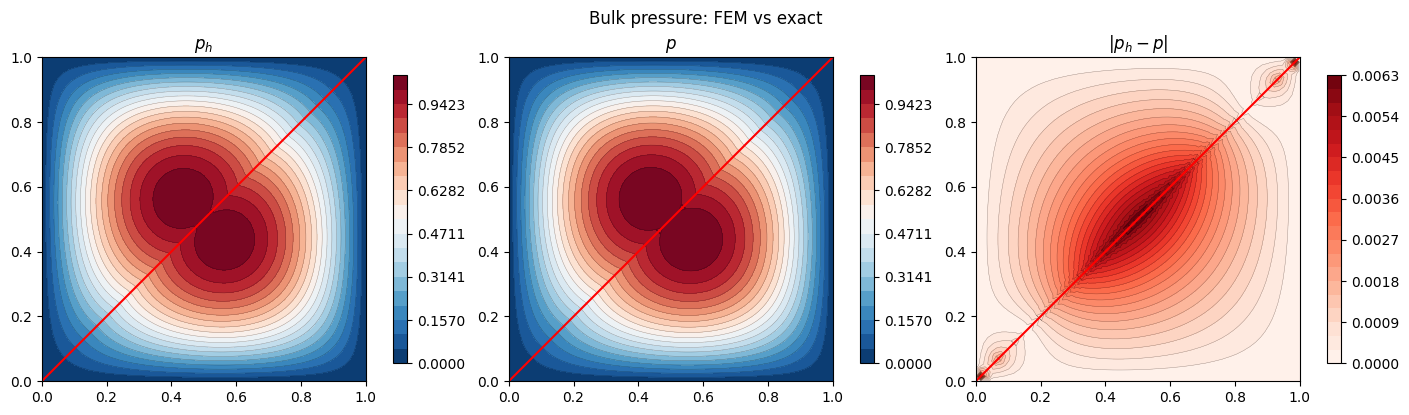

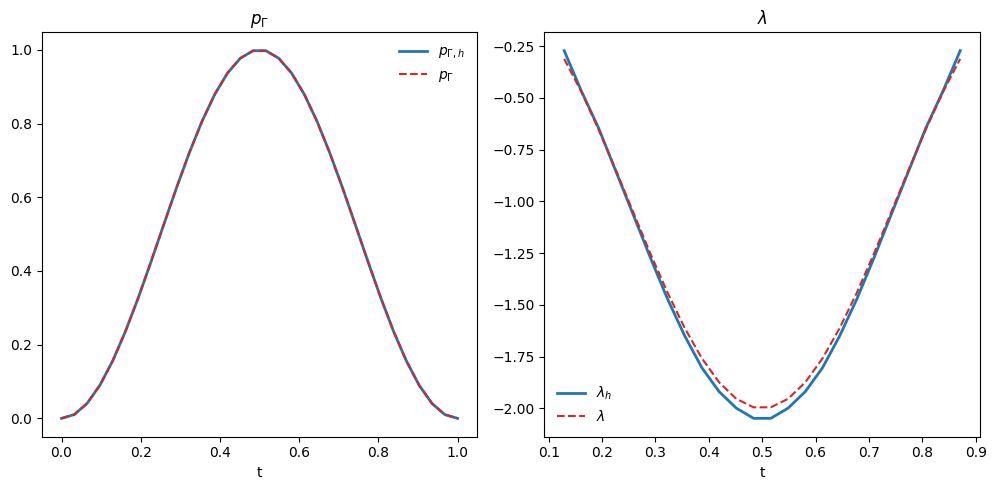

In [6]:
# ── MMS: comparison plots (FEM vs exact) ─────────────────────────────
import matplotlib.tri as mtri

dof_xy, pm_vals = projected_dof_values(V_m, p_m.x.array.copy())
_, pm_ex_vals = projected_dof_values(V_m, p_m_ex.x.array.copy())
pmerr_vals = np.abs(pm_vals - pm_ex_vals)
triang = mtri.Triangulation(dof_xy[:, 0], dof_xy[:, 1])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
vmin, vmax = min(pm_vals.min(), pm_ex_vals.min()), max(pm_vals.max(), pm_ex_vals.max())
levels = np.linspace(vmin, vmax, 21)
for ax, vals, title, cmap, lvl in [
    (axes[0], pm_vals, r"$p_h$", "RdBu_r", levels),
    (axes[1], pm_ex_vals, r"$p$", "RdBu_r", levels),
    (axes[2], pmerr_vals, r"$|p_h-p|$", "Reds", 20),
]:
    cf = ax.tricontourf(triang, vals, levels=lvl, cmap=cmap)
    ax.tricontour(triang, vals, levels=lvl, colors="k", linewidths=0.3, alpha=0.4)
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "r-", lw=1.5, label=r"$\Gamma$")
    fig.colorbar(cf, ax=ax, shrink=0.85)
    ax.set_aspect("equal")
    ax.set_title(title)
plt.suptitle(r"Bulk pressure: FEM vs exact")
plt.show()

# -- p_Gamma and lambda on the independent fracture mesh, sorted by t=s/L --
dof_xy_f = V_f.tabulate_dof_coordinates()[:, :2]
dof_xy_l = V_l.tabulate_dof_coordinates()[:, :2]
s_f = s_coord_points(dof_xy_f)
s_l = s_coord_points(dof_xy_l)
idx_f, idx_l = np.argsort(s_f), np.argsort(s_l)
t_f, t_l = s_f[idx_f] / L_GAMMA_GLOBAL, s_l[idx_l] / L_GAMMA_GLOBAL

pf_fem = p_f.x.array[idx_f]
pf_ex = p_gamma_exact_points(dof_xy_f[idx_f])
lam_fem = lmbd.x.array[idx_l]
lam_ex_plot = lambda_exact_points(dof_xy_l[idx_l])

mask_l = (t_l >= TIP_FRAC) & (t_l <= 1.0 - TIP_FRAC)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(t_f, pf_fem, lw=2, color="tab:blue", label=r"$p_{\Gamma,h}$")
axes[0].plot(t_f, pf_ex, lw=1.5, color="tab:red", linestyle="--", label=r"$p_\Gamma$")
axes[0].set_xlabel("t")
axes[0].set_title(r"$p_\Gamma$")
axes[0].legend(frameon=False); axes[0].grid(False)

axes[1].plot(t_l[mask_l], lam_fem[mask_l], lw=2, color="tab:blue", label=r"$\lambda_h$")
axes[1].plot(t_l[mask_l], lam_ex_plot[mask_l], lw=1.5, color="tab:red", linestyle="--", label=r"$\lambda$")
axes[1].set_xlabel("t")
axes[1].set_title(r"$\lambda$")
axes[1].legend(frameon=False); axes[1].grid(False)

# axes[2].semilogy(t_f, np.abs(pf_fem - pf_ex) + 1e-16, color="tab:blue", label=r"$|p_{\Gamma,h}-p_\Gamma|$")
# axes[2].semilogy(t_l[mask_l], np.abs(lam_fem[mask_l] - lam_ex_plot[mask_l]) + 1e-16,
#                  color="tab:red", label=r"$|\lambda_h-\lambda|$")
# axes[2].set_xlabel("t")
# axes[2].set_title(r"Pointwise errors on $\Gamma$")
# axes[2].legend(frameon=False); axes[2].grid(False)

plt.tight_layout()
plt.show()


## 3. Ghost extension partition


physical fracture: [0. 0.] to [1. 1.] length 1.4142135623730951
ghost line: [0. 0.] to [1. 1.]
tau: [0.70710678 0.70710678] normal: [-0.70710678  0.70710678]


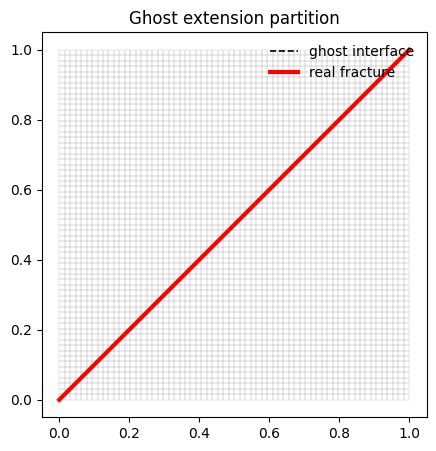

In [7]:
def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0:
        raise ValueError("zero-length vector")
    return v / nrm

def extend_line_to_bbox(a, tau, bbox, tol=1e-14):
    xmin_b, xmax_b, ymin_b, ymax_b = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in [xmin_b, xmax_b]:
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin_b - tol <= y <= ymax_b + tol:
                ts.append(t)
    if abs(tau[1]) > tol:
        for yval in [ymin_b, ymax_b]:
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin_b - tol <= x <= xmax_b + tol:
                ts.append(t)
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box.")
    return min(ts), max(ts)

tau_np = unit(FRAC_B - FRAC_A)
normal_np = np.array([-tau_np[1], tau_np[0]], dtype=float)
L_gamma = float(np.linalg.norm(FRAC_B - FRAC_A))
bbox = np.array([xmin, xmax, ymin, ymax], dtype=float)
t_min, t_max = extend_line_to_bbox(FRAC_A, tau_np, bbox)
GHOST_START = FRAC_A + t_min * tau_np
GHOST_END = FRAC_A + t_max * tau_np

def signed_distance_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ normal_np

def s_coord_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ tau_np

def real_points_np(s):
    s = np.asarray(s, dtype=float).reshape(-1)
    return FRAC_A[None, :] + s[:, None] * tau_np[None, :]

def ghost_points_np(n_each=160):
    pts = []
    if -t_min > 1e-14:
        s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
        pts.append(FRAC_A[None, :] + s_left[:, None] * tau_np[None, :])
    if t_max - L_gamma > 1e-14:
        s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
        pts.append(FRAC_A[None, :] + s_right[:, None] * tau_np[None, :])
    return np.vstack(pts) if pts else np.zeros((0, 2))

print("physical fracture:", FRAC_A, "to", FRAC_B, "length", L_gamma)
print("ghost line:", GHOST_START, "to", GHOST_END)
print("tau:", tau_np, "normal:", normal_np)

plt.figure(figsize=(5, 5))
for poly in cell_polys:
    closed = np.vstack([poly, poly[0]])
    plt.plot(closed[:, 0], closed[:, 1], lw=0.25, color="0.75")
plt.plot([GHOST_START[0], GHOST_END[0]], [GHOST_START[1], GHOST_END[1]], "k--", lw=1.2, label="ghost interface")
plt.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "r-", lw=3, label="real fracture")
plt.gca().set_aspect("equal")
plt.legend(frameon=False)
plt.title("Ghost extension partition")
plt.show()


## 4. Multiplier data and sign convention


In [8]:
# Multiplier integrals for nonconforming line-cell intersections.
EDGE_XI = np.array([0.5 * (1.0 - 1.0 / np.sqrt(3.0)), 0.5 * (1.0 + 1.0 / np.sqrt(3.0))], dtype=float)
EDGE_WI = np.array([0.5, 0.5], dtype=float)

TRI_BARY = np.array([
    [1/3, 1/3, 1/3],
    [0.059715871789770, 0.470142064105115, 0.470142064105115],
    [0.470142064105115, 0.059715871789770, 0.470142064105115],
    [0.470142064105115, 0.470142064105115, 0.059715871789770],
    [0.797426985353087, 0.101286507323456, 0.101286507323456],
    [0.101286507323456, 0.797426985353087, 0.101286507323456],
    [0.101286507323456, 0.101286507323456, 0.797426985353087],
], dtype=float)
TRI_WEIGHTS = np.array([
    0.225,
    0.132394152788506,
    0.132394152788506,
    0.132394152788506,
    0.125939180544827,
    0.125939180544827,
    0.125939180544827,
], dtype=float)

def point_in_convex_polygon(pt, poly, tol=1e-12):
    pt = np.asarray(pt, dtype=float)
    for j in range(len(poly)):
        a = poly[j]
        b = poly[(j + 1) % len(poly)]
        edge = b - a
        cross = edge[0] * (pt[1] - a[1]) - edge[1] * (pt[0] - a[0])
        if cross < -tol:
            return False
    return True

def segment_edge_s_intersection(edge_a, edge_b, tol=1e-12):
    v = edge_b - edge_a
    A = np.column_stack((tau_np, -v))
    det = np.linalg.det(A)
    if abs(det) < tol:
        return None
    rhs = edge_a - FRAC_A
    s, u = np.linalg.solve(A, rhs)
    if -tol <= s <= L_gamma + tol and -tol <= u <= 1.0 + tol:
        return float(np.clip(s, 0.0, L_gamma))
    return None

def fracture_intervals_in_polygon(poly, tol=1e-11):
    candidates = [0.0, L_gamma]
    for j in range(len(poly)):
        s_int = segment_edge_s_intersection(poly[j], poly[(j + 1) % len(poly)])
        if s_int is not None:
            candidates.append(s_int)
    candidates = np.array(sorted(candidates), dtype=float)
    unique = []
    for s in candidates:
        if not unique or abs(s - unique[-1]) > tol:
            unique.append(float(s))
    intervals = []
    for s0, s1 in zip(unique[:-1], unique[1:]):
        if s1 - s0 <= tol:
            continue
        sm = 0.5 * (s0 + s1)
        if point_in_convex_polygon(real_points_np([sm])[0], poly, tol=1e-10):
            intervals.append((s0, s1))
    return intervals

def integrate_source_polygon(poly):
    total = 0.0
    p0 = poly[0]
    for j in range(1, len(poly) - 1):
        tri = np.vstack([p0, poly[j], poly[j + 1]])
        area = abs(polygon_signed_area(tri))
        qpts = TRI_BARY @ tri
        total += area * np.dot(TRI_WEIGHTS, f_m_exact_points(qpts))
    return float(total)

def integrate_flux_polygon(poly):
    flux = 0.0
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        edge = x1 - x0
        n_len = np.array([edge[1], -edge[0]], dtype=float)
        for q, w in zip(EDGE_XI, EDGE_WI):
            pt = x0 + q * edge
            qv = q_cg_numpy(pt[None, :])[0]
            flux += w * np.dot(qv, n_len)
    return float(flux)

def integrate_lambda_interval(s0, s1):
    mid = 0.5 * (s0 + s1)
    half = 0.5 * (s1 - s0)
    sq = mid + half * np.array([-1.0 / np.sqrt(3.0), 1.0 / np.sqrt(3.0)])
    vals = eval_fem_function(lmbd, real_points_np(sq), gamma).reshape(-1)
    return float(half * np.sum(vals))

lambda_h_cell_int_raw = np.zeros(num_cells, dtype=float)
gamma_facet_records = []
for cell_id, poly in enumerate(cell_polys):
    intervals = fracture_intervals_in_polygon(poly)
    for s0, s1 in intervals:
        seg_len = s1 - s0
        lambda_h_cell_int_raw[cell_id] += integrate_lambda_interval(s0, s1)
        gamma_facet_records.append((int(cell_id), float(s0), float(s1), float(seg_len)))

cell_flux_cg = np.array([integrate_flux_polygon(poly) for poly in tqdm(cell_polys, desc="cell q integrals")])
cell_source = np.array([integrate_source_polygon(poly) for poly in tqdm(cell_polys, desc="cell f integrals")])

R_plus = cell_flux_cg - cell_source - lambda_h_cell_int_raw
R_minus = cell_flux_cg - cell_source + lambda_h_cell_int_raw
if np.mean(np.abs(R_plus)) <= np.mean(np.abs(R_minus)):
    LAMBDA_SIGN = 1.0
    lambda_h_cell_int = lambda_h_cell_int_raw
else:
    LAMBDA_SIGN = -1.0
    lambda_h_cell_int = -lambda_h_cell_int_raw

print("fracture-cut cells:", len(np.unique([cid for cid, _, _, _ in gamma_facet_records])))
print("auto LAMBDA_SIGN:", LAMBDA_SIGN)
print("mean |R_CG| with selected lambda_h sign:", np.mean(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))
print("max  |R_CG| with selected lambda_h sign:", np.max(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))

def lambda_h_on_s(s_query):
    pts = real_points_np(np.asarray(s_query, dtype=float).reshape(-1))
    vals = eval_fem_function(lmbd, pts, gamma).reshape(-1)
    return LAMBDA_SIGN * vals


cell f integrals: 100%|██████████| 4096/4096 [00:00<00:00, 8617.57it/s]

fracture-cut cells: 64
auto LAMBDA_SIGN: 1.0
mean |R_CG| with selected lambda_h sign: 0.0004542585049387403
max  |R_CG| with selected lambda_h sign: 0.02884471427077423


## Fracture-segment local conservation residual

For each fracture segment $e=[s_0,s_1]$, compute the 1D local balance using the flux **inside that segment**:

$$
R_e = q_{\Gamma,e}(s_1^-)-q_{\Gamma,e}(s_0^+)+\int_e \lambda_h\,ds-\int_e f_\Gamma\,ds,
\qquad q_{\Gamma,e}=-K_\Gamma\,\partial_s p_{\Gamma,h}ig|_e.
$$

So the endpoint flux is one-sided per segment, not averaged with the neighboring fracture segment. The multiplier orientation follows the same `LAMBDA_SIGN` selected by the matrix local-conservation diagnostic above.


In [ ]:
# Fracture-segment local conservation residual on Gamma.
# Run this after the lambda-sign / matrix conservation setup cell.
# Endpoint fluxes are one-sided values from the current fracture segment e.

def _lagrange_1d_values_and_derivatives(nodes, x):
    nodes = np.asarray(nodes, dtype=float).reshape(-1)
    x = float(x)
    n = len(nodes)
    if n == 1:
        return np.ones(1, dtype=float), np.zeros(1, dtype=float)
    vals = np.ones(n, dtype=float)
    ders = np.zeros(n, dtype=float)
    for i in range(n):
        for j in range(n):
            if i != j:
                vals[i] *= (x - nodes[j]) / (nodes[i] - nodes[j])
        acc = 0.0
        for m in range(n):
            if m == i:
                continue
            term = 1.0 / (nodes[i] - nodes[m])
            for j in range(n):
                if j != i and j != m:
                    term *= (x - nodes[j]) / (nodes[i] - nodes[j])
            acc += term
        ders[i] = acc
    return vals, ders


def _line_function_cells(fun):
    V = fun.function_space
    domain = V.mesh
    tdim_line = domain.topology.dim
    domain.topology.create_connectivity(tdim_line, 0)
    c2v = domain.topology.connectivity(tdim_line, 0)
    num_cells_line = domain.topology.index_map(tdim_line).size_local
    dof_coords = V.tabulate_dof_coordinates()
    cells = []
    for cid in range(num_cells_line):
        verts = np.asarray(c2v.links(cid), dtype=np.int32)
        s_verts = np.asarray(s_coord_np(domain.geometry.x[verts]), dtype=float).reshape(-1)
        s0, s1 = float(np.min(s_verts)), float(np.max(s_verts))
        dofs = np.asarray(V.dofmap.cell_dofs(cid), dtype=np.int32)
        s_nodes = np.asarray(s_coord_np(dof_coords[dofs]), dtype=float).reshape(-1)
        order = np.argsort(s_nodes)
        cells.append({
            "cell": int(cid),
            "s0": s0,
            "s1": s1,
            "dofs": dofs[order],
            "s_nodes": s_nodes[order],
        })
    cells.sort(key=lambda item: (item["s0"], item["s1"]))
    return cells


def _find_line_cell(cells, s, tol=1.0e-12):
    s = float(s)
    for cell in cells:
        if cell["s0"] - tol <= s <= cell["s1"] + tol:
            return cell
    raise ValueError(f"No fracture line cell contains s={s:.16e}")


def _eval_line_function_from_cells(fun, cells, s_query):
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    values = np.asarray(fun.x.array, dtype=float)
    out = np.empty_like(s_query, dtype=float)
    for i, s in enumerate(s_query):
        cell = _find_line_cell(cells, s)
        basis, _ = _lagrange_1d_values_and_derivatives(cell["s_nodes"], s)
        out[i] = float(np.dot(basis, values[cell["dofs"]]))
    return out


def _integrate_line_function(fun, cells, s0, s1, nq=5):
    if s1 - s0 <= 0.0:
        return 0.0
    xi, wi = np.polynomial.legendre.leggauss(int(nq))
    total = 0.0
    breakpoints = [float(s0), float(s1)]
    for cell in cells:
        if s0 < cell["s0"] < s1:
            breakpoints.append(cell["s0"])
        if s0 < cell["s1"] < s1:
            breakpoints.append(cell["s1"])
    breakpoints = np.asarray(sorted(set(np.round(breakpoints, 14))), dtype=float)
    for a, b in zip(breakpoints[:-1], breakpoints[1:]):
        if b - a <= 1.0e-14:
            continue
        sq = 0.5 * (a + b) + 0.5 * (b - a) * xi
        total += 0.5 * (b - a) * float(np.dot(wi, _eval_line_function_from_cells(fun, cells, sq)))
    return float(total)


def _fracture_source_values_on_s(s_query):
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    pts = real_points_np(s_query)
    if "f_gamma_exact_xy" in globals():
        return np.asarray(f_gamma_exact_xy(pts[:, 0], pts[:, 1]), dtype=float).reshape(-1)
    if "f_gamma_exact_fn" in globals():
        return np.asarray(f_gamma_exact_fn(pts.T), dtype=float).reshape(-1)
    if "lam_exact_fn" in globals():
        t = pts[:, 0]
        return -K_F_VALUE * np.pi**2 * np.cos(2.0 * np.pi * t) + lam_exact_fn(t)
    raise RuntimeError("No analytic fracture source helper was found.")


def _integrate_fracture_source(s0, s1, nq=8):
    if s1 - s0 <= 0.0:
        return 0.0
    xi, wi = np.polynomial.legendre.leggauss(int(nq))
    sq = 0.5 * (s0 + s1) + 0.5 * (s1 - s0) * xi
    return float(0.5 * (s1 - s0) * np.dot(wi, _fracture_source_values_on_s(sq)))


def compute_fracture_segment_residuals(nq_lambda=5, nq_source=8):
    pf_cells = _line_function_cells(p_f)
    lam_cells = _line_function_cells(lmbd)
    pvals = np.asarray(p_f.x.array, dtype=float)
    lambda_sign = float(globals().get("LAMBDA_SIGN", 1.0))

    rows = []
    residuals = []
    for local_id, cell in enumerate(pf_cells):
        s0, s1 = cell["s0"], cell["s1"]
        _, dN0 = _lagrange_1d_values_and_derivatives(cell["s_nodes"], s0)
        _, dN1 = _lagrange_1d_values_and_derivatives(cell["s_nodes"], s1)
        q_e_left = -K_F_VALUE * float(np.dot(dN0, pvals[cell["dofs"]]))
        q_e_right = -K_F_VALUE * float(np.dot(dN1, pvals[cell["dofs"]]))
        flux = q_e_right - q_e_left
        lambda_int = lambda_sign * _integrate_line_function(lmbd, lam_cells, s0, s1, nq=nq_lambda)
        source_int = _integrate_fracture_source(s0, s1, nq=nq_source)
        R_e = flux + lambda_int - source_int
        residuals.append(R_e)
        rows.append({
            "segment": local_id,
            "cell": cell["cell"],
            "s0": s0,
            "s1": s1,
            "s_mid": 0.5 * (s0 + s1),
            "q_e_left": q_e_left,
            "q_e_right": q_e_right,
            "flux_boundary": flux,
            "lambda_int": lambda_int,
            "source_int": source_int,
            "R_e": R_e,
            "abs_R_e": abs(R_e),
        })

    residuals = np.asarray(residuals, dtype=float)
    stats = {
        "n_segments": int(residuals.size),
        "mean_abs": float(np.mean(np.abs(residuals))) if residuals.size else np.nan,
        "max_abs": float(np.max(np.abs(residuals))) if residuals.size else np.nan,
    }
    return rows, residuals, stats


fracture_segment_rows, R_gamma_e, fracture_segment_stats = compute_fracture_segment_residuals()
print("Fracture-segment residual R_e = q_Gamma,e(s1-) - q_Gamma,e(s0+) + int_e lambda_h ds - int_e f_Gamma ds")
print(f"  segments     = {fracture_segment_stats['n_segments']}")
print(f"  mean |R_e|   = {fracture_segment_stats['mean_abs']:.6e}")
print(f"  max  |R_e|   = {fracture_segment_stats['max_abs']:.6e}")

try:
    import pandas as pd
    fracture_segment_residual_table = pd.DataFrame(fracture_segment_rows)
    display(fracture_segment_residual_table)
except Exception:
    fracture_segment_residual_table = fracture_segment_rows
    print(fracture_segment_rows[:5])


## 5. Interface target: lambda_h or CG flux jump


CONSERVATION_TARGET: lambda_h (using fenicsx_ii multiplier sign-selected in Section 4)


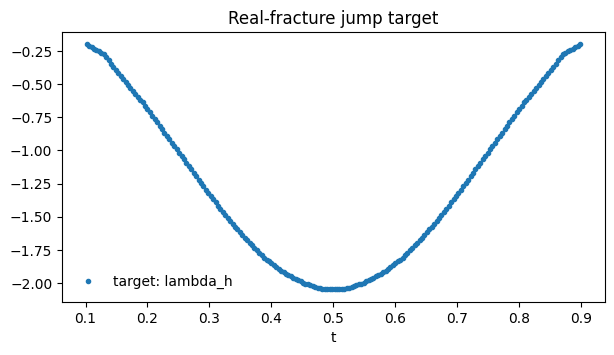

In [9]:
TARGET_MODE = "lambda_h"          # options: "lambda_h" or "cg_jump"
CONSERVATION_TARGET = "lambda_h"  # options: "lambda_h" or "cg_jump"
TIP_RADIUS_FACTOR = 10.0

def cg_jump_on_fracture(s_query, eps=None):
    if eps is None:
        eps = 0.00 * h_est
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    x0 = real_points_np(s_query)
    # For a boundary-to-boundary fracture, a fixed normal offset leaves Omega
    # near the tips.  Shrink the offset there; the tip weight is zero anyway.
    d_tip = np.minimum(s_query, L_gamma - s_query)
    eps_eff = np.minimum(float(eps), 0.45 * np.maximum(d_tip, 0.0))
    qp = q_cg_numpy(x0 + eps_eff[:, None] * normal_np[None, :])
    qm = q_cg_numpy(x0 - eps_eff[:, None] * normal_np[None, :])
    jump = np.sum((qp - qm) * normal_np[None, :], axis=1)
    return np.nan_to_num(jump, nan=0.0, posinf=0.0, neginf=0.0)

N_REAL = max(128, 4 * max(1, len(gamma_facet_records)))
s_real = np.linspace(0.0, L_gamma, N_REAL)
x_real = real_points_np(s_real)
x_ghost = ghost_points_np(n_each=max(64, N_REAL // 2))

if TARGET_MODE == "lambda_h":
    lambda_target = lambda_h_on_s(s_real)
elif TARGET_MODE == "cg_jump":
    lambda_target = cg_jump_on_fracture(s_real)
else:
    raise ValueError("TARGET_MODE must be 'lambda_h' or 'cg_jump'.")

def tip_weight_np(s):
    s = np.asarray(s, dtype=float)
    d = np.minimum(s, L_gamma - s)
    radius = TIP_RADIUS_FACTOR * h_est
    return np.clip(d / max(radius, 1e-14), 0.0, 1.0)

w_tip = tip_weight_np(s_real)
t_real = s_real / L_gamma
x_coords = t_real
mask_cmp = (t_real >= TIP_FRAC) & (t_real <= 1.0 - TIP_FRAC)

if CONSERVATION_TARGET == "cg_jump":
    s_mids = np.array([0.5 * (s0 + s1) for _, s0, s1, _ in gamma_facet_records])
    seg_lengths = np.array([seg_len for _, _, _, seg_len in gamma_facet_records])
    cg_vals = cg_jump_on_fracture(s_mids)
    conservation_cell_int = np.zeros(num_cells, dtype=float)
    for i, (cell_id, s0, s1, seg_len) in enumerate(gamma_facet_records):
        conservation_cell_int[int(cell_id)] += seg_lengths[i] * cg_vals[i]
    lambda_h_cell_int = conservation_cell_int
    print("CONSERVATION_TARGET: CG flux jump -> lambda_h_cell_int updated")
elif CONSERVATION_TARGET == "lambda_h":
    print("CONSERVATION_TARGET: lambda_h (using fenicsx_ii multiplier sign-selected in Section 4)")
else:
    raise ValueError("CONSERVATION_TARGET must be 'lambda_h' or 'cg_jump'.")

plt.figure(figsize=(7, 3.5))
plt.plot(x_coords[mask_cmp], lambda_target[mask_cmp], "o", ms=3, label=f"target: {TARGET_MODE}")
plt.xlabel("t")
plt.legend(frameon=False)
plt.title("Real-fracture jump target")
plt.show()


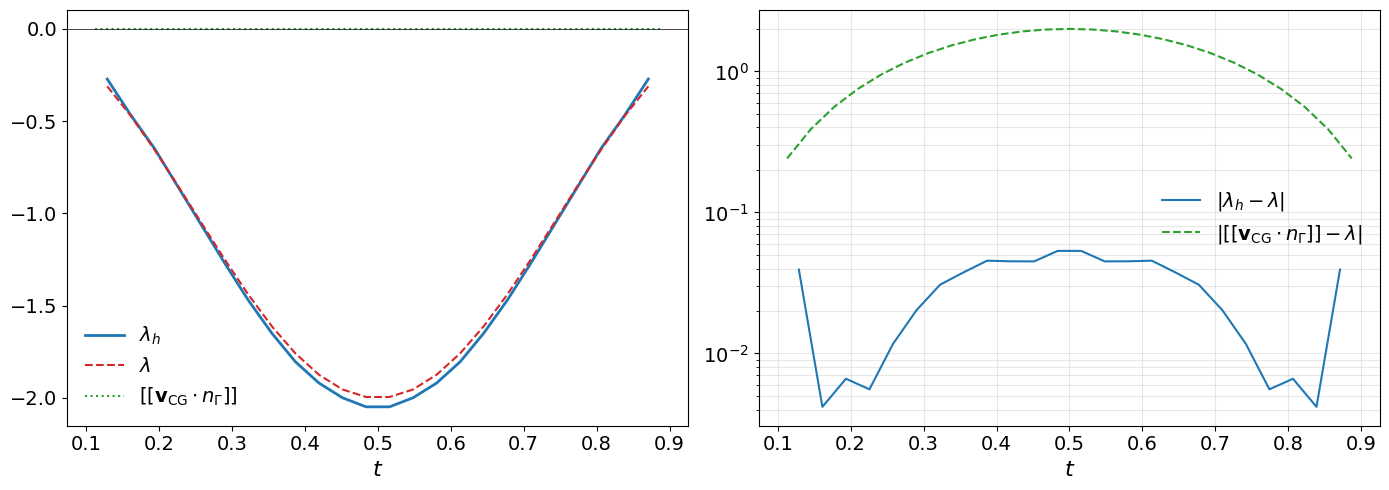

L2 err lambda_h          (excl. 10% tips): 2.865e-02
L2 err [[q_cg*n]] midpts (excl. 10% tips): 1.224e+00
Default PINN target for this nonconforming notebook: lambda_h


/tmp/ipykernel_2018849/2893023823.py:50: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  l2_lh = np.sqrt(np.trapz((lam_h_cmp[mask_cmp] - lam_ex_cmp[mask_cmp]) ** 2, t_in))
/tmp/ipykernel_2018849/2893023823.py:52: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  l2_cg = np.sqrt(np.trapz((cg_jump_mid[mask_mid] - lam_ex_mid[mask_mid]) ** 2, t_in_mid))


In [10]:
# ── Lambda / flux-jump comparison ─────────────────────────────────────
dof_xy_l_cmp = V_l.tabulate_dof_coordinates()[:, :2]
s_l_cmp_all = s_coord_np(dof_xy_l_cmp)
idx_l_cmp = np.argsort(s_l_cmp_all)
s_l_cmp = s_l_cmp_all[idx_l_cmp]
t_l_cmp = s_l_cmp / L_gamma

lam_h_cmp = LAMBDA_SIGN * lmbd.x.array[idx_l_cmp]
lam_ex_cmp = lambda_exact_points(dof_xy_l_cmp[idx_l_cmp])

s_mid = 0.5 * (s_l_cmp[:-1] + s_l_cmp[1:])
t_mid = s_mid / L_gamma
cg_jump_mid = cg_jump_on_fracture(s_mid)
lam_ex_mid = lambda_exact_points(real_points_np(s_mid))

mask_cmp = (t_l_cmp >= TIP_FRAC) & (t_l_cmp <= 1.0 - TIP_FRAC)
mask_mid = (t_mid >= TIP_FRAC) & (t_mid <= 1.0 - TIP_FRAC)

fs_label = 16
fs_title = 17
fs_tick = 14
fs_legend = 14
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t_l_cmp[mask_cmp], lam_h_cmp[mask_cmp], lw=2, color="tab:blue", label=r"$\lambda_h$")
axes[0].plot(t_l_cmp[mask_cmp], lam_ex_cmp[mask_cmp], lw=1.5, ls="--", color="tab:red", label=r"$\lambda$")
axes[0].plot(t_mid[mask_mid], cg_jump_mid[mask_mid], lw=1.5, ls=":", color="tab:green",
             label=r"$[[\mathbf{v}_{\rm CG}\cdot n_\Gamma]]$")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_xlabel(r"$t$", fontsize=fs_label)
# axes[0].set_title(r"$\lambda,\ [[\mathbf{v}_{\rm CG}\cdot n_\Gamma]]$", fontsize=fs_title)
axes[0].tick_params(axis="both", labelsize=fs_tick)
axes[0].legend(fontsize=fs_legend, frameon=False)
axes[0].grid(False)

axes[1].semilogy(t_l_cmp[mask_cmp], np.abs(lam_h_cmp[mask_cmp] - lam_ex_cmp[mask_cmp]) + 1e-16,
                 lw=1.5, color="tab:blue", label=r"$|\lambda_h-\lambda|$")
axes[1].semilogy(t_mid[mask_mid], np.abs(cg_jump_mid[mask_mid] - lam_ex_mid[mask_mid]) + 1e-16,
                 lw=1.5, ls="--", color="tab:green", label=r"$|[[\mathbf{v}_{\rm CG}\cdot n_\Gamma]]-\lambda|$")
axes[1].set_xlabel(r"$t$", fontsize=fs_label)
# axes[1].set_title(r"$|\cdot-\lambda|$", fontsize=fs_title)
axes[1].tick_params(axis="both", labelsize=fs_tick)
axes[1].legend(fontsize=fs_legend, frameon=False)
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

t_in = t_l_cmp[mask_cmp]
l2_lh = np.sqrt(np.trapz((lam_h_cmp[mask_cmp] - lam_ex_cmp[mask_cmp]) ** 2, t_in))
t_in_mid = t_mid[mask_mid]
l2_cg = np.sqrt(np.trapz((cg_jump_mid[mask_mid] - lam_ex_mid[mask_mid]) ** 2, t_in_mid))
print(f"L2 err lambda_h          (excl. {TIP_FRAC*100:.0f}% tips): {l2_lh:.3e}")
print(f"L2 err [[q_cg*n]] midpts (excl. {TIP_FRAC*100:.0f}% tips): {l2_cg:.3e}")
print("Default PINN target for this nonconforming notebook:", TARGET_MODE)


## 5b. CG conservation diagnostic on nonconforming cut cells


Nonconforming CG conservation diagnostic
  fracture-cut cells: 64
All cells, $R_K$ with fracture source:
  mean |R_K| = 4.543e-04
  max  |R_K| = 2.884e-02
Fracture-cut cells, $R_K$ with fracture source:
  mean |R_K| = 1.275e-02
  max  |R_K| = 2.884e-02


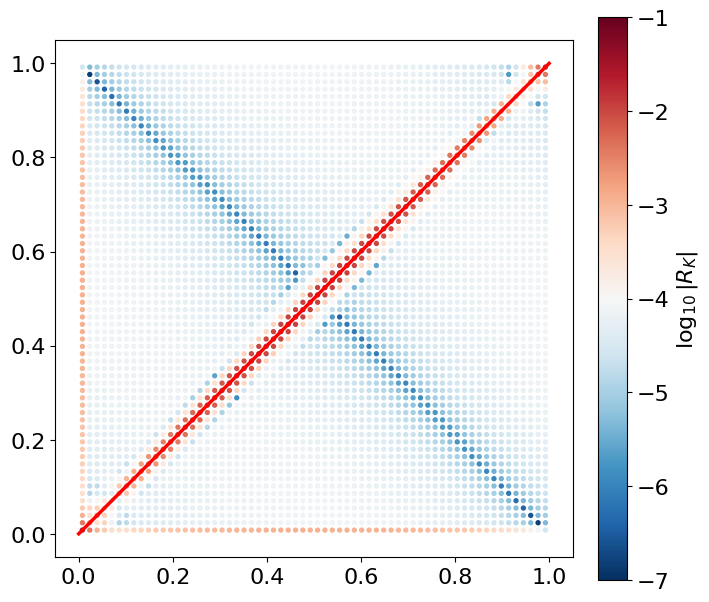

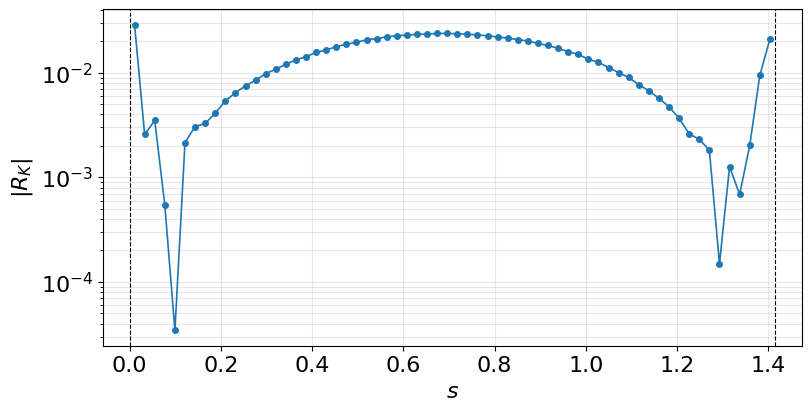

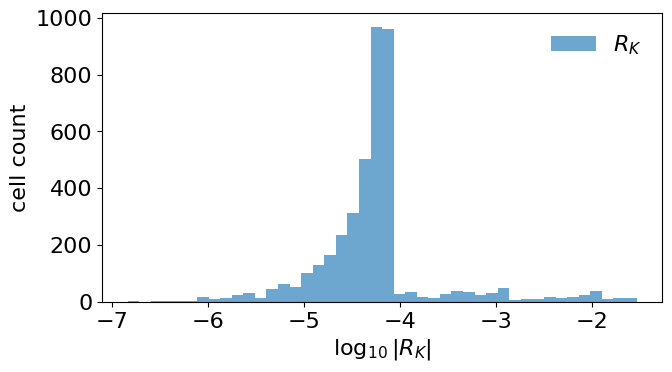

In [11]:
# CG-only diagnostic for nonconforming fracture-cut cells.
# This cell does not modify lambda_h_cell_int or any PINN training arrays.
# The nonconforming fracture is internal to each cut cell, so every cut cell
# receives its own full integral int_{Gamma cap K} lambda_h ds.

rk_eps_diag = 1e-16
# Common residual-map scale used for conforming/nonconforming comparison.
# Values outside [10^{-7}, 10^{-1}] are intentionally saturated so the colorbars match.
RK_LOG_VMIN = -7.0
RK_LOG_VMAX = -1.0
RK_CBAR_TICKS = np.array([-7, -6, -5, -4, -3, -2, -1], dtype=float)
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
})

all_cell_ids_diag = np.arange(num_cells, dtype=np.int32)
frac_cell_ids_diag = np.unique([cell_id for cell_id, _, _, _ in gamma_facet_records]).astype(np.int32)

# Physical nonconforming balance with the line-cell multiplier source included.
R_cg_nonconf_diag = cell_flux_cg - cell_source - lambda_h_cell_int

# Use the midpoint of Gamma cap K as the abscissa for fracture-cut cells.
frac_seg_len_diag = np.zeros(num_cells, dtype=float)
frac_s_weighted_diag = np.zeros(num_cells, dtype=float)
for cell_id, s0, s1, seg_len in gamma_facet_records:
    cell_id = int(cell_id)
    smid = 0.5 * (float(s0) + float(s1))
    seg_len = float(seg_len)
    frac_seg_len_diag[cell_id] += seg_len
    frac_s_weighted_diag[cell_id] += seg_len * smid
frac_s_mid_diag = np.zeros(num_cells, dtype=float)
nonzero_frac_len_diag = frac_seg_len_diag > 0.0
frac_s_mid_diag[nonzero_frac_len_diag] = (
    frac_s_weighted_diag[nonzero_frac_len_diag] / frac_seg_len_diag[nonzero_frac_len_diag]
)


def print_rk_summary_diag(name, R, ids=None):
    vals = np.asarray(R if ids is None else R[ids], dtype=float)
    print(f"{name}:")
    print(f"  mean |R_K| = {np.mean(np.abs(vals)):.3e}")
    print(f"  max  |R_K| = {np.max(np.abs(vals)):.3e}")


print("Nonconforming CG conservation diagnostic")
print(f"  fracture-cut cells: {len(frac_cell_ids_diag)}")
print_rk_summary_diag(r"All cells, $R_K$ with fracture source", R_cg_nonconf_diag)
print_rk_summary_diag(r"Fracture-cut cells, $R_K$ with fracture source", R_cg_nonconf_diag, frac_cell_ids_diag)

# Figure 1: residual maps over all projected cells.
log_nonconf_diag = np.log10(np.abs(R_cg_nonconf_diag) + rk_eps_diag)
vmin_diag = RK_LOG_VMIN
vmax_diag = RK_LOG_VMAX
extend_diag = "both" if (log_nonconf_diag.min() < RK_LOG_VMIN and log_nonconf_diag.max() > RK_LOG_VMAX) else (
    "min" if log_nonconf_diag.min() < RK_LOG_VMIN else ("max" if log_nonconf_diag.max() > RK_LOG_VMAX else "neither")
)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
sc = ax.scatter(
    cell_centroids[:, 0], cell_centroids[:, 1],
    c=log_nonconf_diag,
    s=8, cmap="RdBu_r", vmin=vmin_diag, vmax=vmax_diag,
)
ax.plot([GHOST_START[0], GHOST_END[0]], [GHOST_START[1], GHOST_END[1]], "k--", lw=1)
ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "r-", lw=2.5)
ax.set_aspect("equal")
# ax.set_title(r"CG residual $R_K$")
cbar = fig.colorbar(sc, ax=ax, label=r"$\log_{10}|R_K|$", extend=extend_diag)
cbar.set_ticks(RK_CBAR_TICKS)
plt.show()

# Figure 2: residuals on fracture-cut cells along the fracture.
if len(frac_cell_ids_diag):
    s_frac_diag = frac_s_mid_diag[frac_cell_ids_diag]
    idx_frac_diag = np.argsort(s_frac_diag)

    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.semilogy(
        s_frac_diag[idx_frac_diag],
        np.abs(R_cg_nonconf_diag[frac_cell_ids_diag][idx_frac_diag]) + rk_eps_diag,
        "o-", ms=4, lw=1.2, label=r"$R_K$",
    )
    ax.axvline(0.0, color="k", ls="--", lw=0.8)
    ax.axvline(L_gamma, color="k", ls="--", lw=0.8)
    ax.set_xlabel(r"$s$")
    ax.set_ylabel(r"$|R_K|$")
    # ax.set_title(r"CG residual on fracture-cut cells")
    ax.grid(True, which="both", alpha=0.3)
    # ax.legend(frameon=False)
    plt.show()

# Figure 3: distribution over all cells.
bins_diag = np.linspace(log_nonconf_diag.min(), log_nonconf_diag.max(), 45)
plt.figure(figsize=(7, 4))
plt.hist(log_nonconf_diag, bins=bins_diag, alpha=0.65, label=r"$R_K$")
plt.xlabel(r"$\log_{10}|R_K|$")
plt.ylabel("cell count")
plt.grid(False)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()



## 6. Neural flux model


In [12]:
class AdaptiveTanh(nn.Module):
    def __init__(self, n=5.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(1.0 / n))
    def forward(self, x):
        return torch.tanh(self.a * x)

class FluxNet(nn.Module):
    def __init__(self, in_dim=2, out_dim=2, hidden_dim=64, num_hidden_layers=4, n=5.0):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), AdaptiveTanh(n=n)]
        for _ in range(num_hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), AdaptiveTanh(n=n)]
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)
    def slope_recovery_term(self):
        slopes = [m.a for m in self.net if isinstance(m, AdaptiveTanh)]
        return 1.0 / torch.mean(torch.exp(torch.stack(slopes)))

xy_center_np = np.array([(xmin + xmax) / 2.0, (ymin + ymax) / 2.0], dtype=float)
xy_scale = float(max(xmax - xmin, ymax - ymin))

xy_center_t = torch.tensor(xy_center_np, dtype=torch.float32, device=device)
tau_t        = torch.tensor(tau_np,       dtype=torch.float32, device=device)
normal_t     = torch.tensor(normal_np,    dtype=torch.float32, device=device)
frac_a_t     = torch.tensor(FRAC_A,      dtype=torch.float32, device=device)

def to_torch(x, requires_grad=False):
    t = torch.as_tensor(np.asarray(x, dtype=np.float32), device=device)
    if requires_grad:
        t = t.clone().detach().requires_grad_(True)
    return t

def normalize_xy(x):
    return (x - xy_center_t) / xy_scale

q_plus_net = FluxNet(hidden_dim=32, num_hidden_layers=3).to(device)
q_minus_net = FluxNet(hidden_dim=32, num_hidden_layers=3).to(device)

def signed_distance_torch(x):
    return (x - frac_a_t) @ normal_t

def s_coord_torch(x):
    return (x - frac_a_t) @ tau_t

def q_plus(x):
    return q_plus_net(normalize_xy(x))

def q_minus(x):
    return q_minus_net(normalize_xy(x))

def q_piecewise(x):
    phi = signed_distance_torch(x)
    qp = q_plus(x)
    qm = q_minus(x)
    return torch.where((phi >= 0.0).reshape(-1, 1), qp, qm)

def div_of_q(net_fn, x):
    x = x.clone().detach().requires_grad_(True)
    q = net_fn(x)
    dq0 = torch.autograd.grad(q[:, 0].sum(), x, create_graph=True)[0][:, 0]
    dq1 = torch.autograd.grad(q[:, 1].sum(), x, create_graph=True)[0][:, 1]
    return dq0 + dq1


## 7. Training data


In [13]:
N_PTS_PER_EDGE = 3  # sample points per projected mesh edge
MASK_FACTOR_START = 0.15
MASK_FACTOR_END = 1.15

# Flux data at projected edge sample points, away from the fracture.
edge_sample_pts = []
for x0, x1 in shadow_edges:
    ts = np.linspace(0.0, 1.0, N_PTS_PER_EDGE + 2)[1:-1]
    for t in ts:
        edge_sample_pts.append(x0 + t * (x1 - x0))
edge_sample_pts = np.array(edge_sample_pts, dtype=float)

phi_edge = signed_distance_np(edge_sample_pts)
Q_data_all = q_cg_numpy(edge_sample_pts)
valid = np.all(np.isfinite(Q_data_all), axis=1)
X_data = edge_sample_pts[valid]
Q_data = Q_data_all[valid]
phi_data = phi_edge[valid]
data_mask = np.abs(phi_data) > MASK_FACTOR_START * h_est
data_mask_final = np.abs(phi_data) > MASK_FACTOR_END * h_est

X_data_t = to_torch(X_data)
Q_data_t = to_torch(Q_data)
data_idx_start_t = torch.tensor(np.nonzero(data_mask)[0], dtype=torch.long, device=device)
data_idx_final_t = torch.tensor(np.nonzero(data_mask_final)[0], dtype=torch.long, device=device)

X_div = cell_centroids
phi_div = signed_distance_np(X_div)
div_mask = np.abs(phi_div) > MASK_FACTOR_START * h_est
div_mask_final = np.abs(phi_div) > MASK_FACTOR_END * h_est
F_div = f_numpy(X_div)
X_div_t = to_torch(X_div)
F_div_t = to_torch(F_div)
div_idx_start_t = torch.tensor(np.nonzero(div_mask)[0], dtype=torch.long, device=device)
div_idx_final_t = torch.tensor(np.nonzero(div_mask_final)[0], dtype=torch.long, device=device)
side_div_t = signed_distance_torch(X_div_t) >= 0.0

X_real_t = to_torch(x_real)
Lambda_target_t = to_torch(lambda_target)
W_tip_t = to_torch(w_tip)
X_ghost_t = to_torch(x_ghost)

print(f"flux data pool (edge-sampled, {N_PTS_PER_EDGE} pts/edge):", len(X_data))
print(f"data_mask points ({MASK_FACTOR_START:.2f}h -> {MASK_FACTOR_END:.2f}h):", np.count_nonzero(data_mask), "->", np.count_nonzero(data_mask_final))
print("div collocation pool:", len(X_div))
print(f"div_mask points ({MASK_FACTOR_START:.2f}h -> {MASK_FACTOR_END:.2f}h):", np.count_nonzero(div_mask), "->", np.count_nonzero(div_mask_final))
print("real interface points:", len(x_real))
print("ghost interface points:", len(x_ghost))

def build_edge_quadrature_for_cells(cell_ids):
    xi = np.array([0.5 * (1 - 1 / np.sqrt(3)), 0.5 * (1 + 1 / np.sqrt(3))], dtype=float)
    wi = np.array([0.5, 0.5], dtype=float)
    edge_points, edge_nw, edge_cells = [], [], []
    is_gamma_edge = []
    source, cg_flux, lambda_h_int = [], [], []
    local_id_of_cell = {}
    for local_i, cell_id in enumerate(cell_ids):
        local_id_of_cell[int(cell_id)] = local_i
        poly = cell_polys[int(cell_id)]
        source.append(cell_source[int(cell_id)])
        cg_flux.append(cell_flux_cg[int(cell_id)])
        lambda_h_int.append(lambda_h_cell_int[int(cell_id)])
        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            n_len = np.array([edge[1], -edge[0]], dtype=float)
            for q, w in zip(xi, wi):
                pt = x0 + q * edge
                edge_points.append(pt)
                edge_nw.append(w * n_len)
                edge_cells.append(local_i)
                # The fracture is an internal nonconforming source, not a projected cell edge.
                is_gamma_edge.append(False)
    return {
        "cell_ids": np.asarray(cell_ids, dtype=np.int32),
        "edge_points": np.asarray(edge_points),
        "edge_nw": np.asarray(edge_nw),
        "edge_cells": np.asarray(edge_cells, dtype=np.int64),
        "is_gamma_edge": np.asarray(is_gamma_edge, dtype=bool),
        "source": np.asarray(source),
        "cg_flux": np.asarray(cg_flux),
        "lambda_h_int": np.asarray(lambda_h_int),
        "local_id_of_cell": local_id_of_cell,
    }

def attach_gamma_facets_to_cell_data(data):
    gamma_cell_local, gamma_s0, gamma_s1, gamma_segment_length = [], [], [], []
    local_id_of_cell = data["local_id_of_cell"]
    for cell_id, s0, s1, seg_len in gamma_facet_records:
        if cell_id in local_id_of_cell:
            gamma_cell_local.append(local_id_of_cell[cell_id])
            gamma_s0.append(s0)
            gamma_s1.append(s1)
            gamma_segment_length.append(seg_len)
    data["gamma_cell_local"] = np.asarray(gamma_cell_local, dtype=np.int64)
    data["gamma_s0"] = np.asarray(gamma_s0, dtype=float)
    data["gamma_s1"] = np.asarray(gamma_s1, dtype=float)
    data["gamma_half_length"] = np.asarray(gamma_segment_length, dtype=float)
    return data


flux data pool (edge-sampled, 3 pts/edge): 24960
data_mask points (0.15h -> 1.15h): 24960 -> 23688
div collocation pool: 4096
div_mask points (0.15h -> 1.15h): 4032 -> 3906
real interface points: 256
ghost interface points: 0


## 8. Train


In [14]:
W_DATA      = 5.0
W_DIV       = 1.0
W_CONS_INT  = 1.0     # final interior fracture-adjacent conservation weight after ramp
W_CONS_TIP  = 1.0     # final tip fracture-adjacent conservation weight after ramp
CONS_INT_BETA = 1.0   # target: |R_PINN| <= beta * |R_CG| away from tips
CONS_R_FLOOR = 1e-5   # normalization floor for very small CG residuals
CONS_INT_GAMMA = 4.0  # extra penalty multiplier when PINN residual exceeds beta*CG
W_JUMP      = 1.0
W_GHOST     = 2.0
W_SLOPE     = 1e-4

EPOCHS = 5000
CONS_RAMP_START_FRAC = 0.60
CONS_RAMP_END_FRAC   = 0.90
CONS_RAMP_START = int(CONS_RAMP_START_FRAC * EPOCHS)
CONS_RAMP_END   = int(CONS_RAMP_END_FRAC   * EPOCHS)
BEST_START_EPOCH = CONS_RAMP_END
LR_PLUS  = 2e-3
LR_MINUS = 2e-3
PRINT_EVERY = 250

BATCH_DATA = 8192   # flux data points sampled per step
BATCH_DIV  = 4096   # div collocation points per step

# Precompute edge quadrature for fracture-adjacent cells (used in conservation loss).
_frac_cids = np.unique([cid for cid, _, _, _ in gamma_facet_records])
_frac_quad = build_edge_quadrature_for_cells(_frac_cids)
N_frac_cons = len(_frac_cids)
frac_eq_pts_t      = to_torch(_frac_quad["edge_points"])
frac_eq_nw_t       = to_torch(_frac_quad["edge_nw"])
frac_eq_cells_t    = torch.tensor(_frac_quad["edge_cells"],    dtype=torch.long, device=device)
frac_eq_is_gamma_t = torch.tensor(_frac_quad["is_gamma_edge"], dtype=torch.bool, device=device)
frac_source_t      = to_torch(_frac_quad["source"])
frac_lambda_t      = to_torch(_frac_quad["lambda_h_int"])
# Non-fracture-edge indices (precomputed once; mask is fixed).
nf_mask          = ~frac_eq_is_gamma_t
frac_eq_pts_nf   = frac_eq_pts_t[nf_mask]
frac_eq_nw_nf    = frac_eq_nw_t[nf_mask]
frac_eq_cells_nf = frac_eq_cells_t[nf_mask]

# Same corrected residual for CG, evaluated on the same non-fracture-edge quadrature.
_nf_np = ~_frac_quad["is_gamma_edge"]
_q_cg_nf = q_cg_numpy(_frac_quad["edge_points"][_nf_np])
_flux_cg_q = np.sum(_q_cg_nf * _frac_quad["edge_nw"][_nf_np], axis=1)
_flux_cg_K = np.zeros(N_frac_cons, dtype=float)
np.add.at(_flux_cg_K, _frac_quad["edge_cells"][_nf_np], _flux_cg_q)
frac_R_cg_np = _flux_cg_K - _frac_quad["source"] - _frac_quad["lambda_h_int"]
frac_R_cg_t = to_torch(frac_R_cg_np)

# Split the conservation objective: interior must improve CG, tips are bounded separately.
frac_s_np = s_coord_np(cell_centroids[_frac_cids])
frac_cons_tip_np = (frac_s_np < TIP_FRAC * L_gamma) | (frac_s_np > (1.0 - TIP_FRAC) * L_gamma)
frac_cons_int_np = ~frac_cons_tip_np
frac_cons_tip_t = torch.tensor(frac_cons_tip_np, dtype=torch.bool, device=device)
frac_cons_int_t = torch.tensor(frac_cons_int_np, dtype=torch.bool, device=device)
print(f"fracture-adjacent cells for conservation loss: {N_frac_cons}")
print(f"  total quad pts: {len(frac_eq_pts_t)},  non-fracture-edge pts: {nf_mask.sum().item()}")
print(f"  interior cells: {np.count_nonzero(frac_cons_int_np)},  tip cells: {np.count_nonzero(frac_cons_tip_np)}")
print(f"curriculum: conservation ramp epochs {CONS_RAMP_START}-{CONS_RAMP_END}; data_mask/div_mask switch at epoch {CONS_RAMP_START}: {MASK_FACTOR_START:.2f}h -> {MASK_FACTOR_END:.2f}h; best tracked from epoch {BEST_START_EPOCH}")

optimizer_plus  = torch.optim.Adam(q_plus_net.parameters(),  lr=LR_PLUS)
optimizer_minus = torch.optim.Adam(q_minus_net.parameters(), lr=LR_MINUS)
scheduler_plus  = torch.optim.lr_scheduler.MultiStepLR(
    optimizer_plus,
    milestones=[int(0.45 * EPOCHS), int(0.75 * EPOCHS)],
    gamma=0.35,
)
scheduler_minus = torch.optim.lr_scheduler.MultiStepLR(
    optimizer_minus,
    milestones=[int(0.45 * EPOCHS), int(0.75 * EPOCHS)],
    gamma=0.35,
)

n_data = len(X_data_t)
n_div  = len(X_div_t)

def mse(x):
    return torch.mean(x ** 2)

def smoothstep01(t):
    t = float(np.clip(t, 0.0, 1.0))
    return t * t * (3.0 - 2.0 * t)

def curriculum_for_epoch(epoch):
    if CONS_RAMP_END <= CONS_RAMP_START:
        ramp = 1.0
    else:
        t = (epoch - CONS_RAMP_START) / (CONS_RAMP_END - CONS_RAMP_START)
        ramp = smoothstep01(t)
    use_final_mask = epoch >= CONS_RAMP_START
    mask_factor = MASK_FACTOR_END if use_final_mask else MASK_FACTOR_START
    data_pool = data_idx_final_t if use_final_mask else data_idx_start_t
    div_pool = div_idx_final_t if use_final_mask else div_idx_start_t
    return ramp, mask_factor, data_pool, div_pool

def compute_loss_terms(epoch):
    cons_ramp, mask_factor, data_pool, div_pool = curriculum_for_epoch(epoch)

    # mini-batch flux data with a two-stage data_mask switch
    n_data_epoch = data_pool.numel()
    if n_data_epoch == 0:
        raise RuntimeError("data_mask removed all flux data points; reduce MASK_FACTOR_END")
    idx_d = data_pool[torch.randint(0, n_data_epoch, (min(BATCH_DATA, n_data_epoch),), device=device)]
    x_d   = X_data_t[idx_d]
    q_d   = Q_data_t[idx_d]
    loss_data = mse(q_piecewise(x_d) - q_d)

    # mini-batch div collocation with the same two-stage div_mask switch
    n_div_epoch = div_pool.numel()
    if n_div_epoch == 0:
        raise RuntimeError("div_mask removed all collocation points; reduce MASK_FACTOR_END")
    idx_v   = div_pool[torch.randint(0, n_div_epoch, (min(BATCH_DIV, n_div_epoch),), device=device)]
    x_div_b = X_div_t[idx_v]
    f_div_b = F_div_t[idx_v]
    side_b  = side_div_t[idx_v]

    div_loss = torch.tensor(0.0, device=device)
    Xp = x_div_b[side_b];  fp = f_div_b[side_b]
    Xm = x_div_b[~side_b]; fm = f_div_b[~side_b]
    if Xp.numel() > 0:
        div_loss = div_loss + mse(div_of_q(q_plus, Xp) - fp)
    if Xm.numel() > 0:
        div_loss = div_loss + mse(div_of_q(q_minus, Xm) - fm)

    # Conservation loss for fracture-adjacent elements.
    # Only non-fracture edges contribute to the flux integral;
    # the fracture acts as a source term lambda_h_int[K] on the RHS.
    # Balance: int_{e1}+int_{e2} q.n ds = int_K f dx + lambda_h_int[K]
    q_nf = q_piecewise(frac_eq_pts_nf)
    flux_q = torch.sum(q_nf * frac_eq_nw_nf, dim=1)
    flux_K = torch.zeros(N_frac_cons, device=device)
    flux_K.scatter_add_(0, frac_eq_cells_nf, flux_q)
    R_rec_frac = flux_K - frac_source_t - frac_lambda_t
    loss_cons_frac = mse(R_rec_frac)  # logged for comparison with the previous absolute loss

    loss_cons_int = torch.tensor(0.0, device=device)
    if frac_cons_int_t.any().item():
        R_rec_int = R_rec_frac[frac_cons_int_t]
        R_cg_int = frac_R_cg_t[frac_cons_int_t]
        R_cg_abs = torch.abs(R_cg_int)
        denom = torch.clamp(R_cg_abs, min=CONS_R_FLOOR)
        r_norm = R_rec_int / denom
        excess = torch.relu(torch.abs(R_rec_int) - CONS_INT_BETA * R_cg_abs)
        # base term always pushes R_K(q_theta)->0; extra term penalises when worse than CG
        loss_cons_int = torch.mean(r_norm ** 2) + CONS_INT_GAMMA * torch.mean((excess / denom) ** 2)

    loss_cons_tip = torch.tensor(0.0, device=device)
    if frac_cons_tip_t.any().item():
        loss_cons_tip = mse(R_rec_frac[frac_cons_tip_t])

    # full interface / ghost / slope (small tensors, always use all)
    qp_real = q_plus(X_real_t)
    qm_real = q_minus(X_real_t)
    jump_real = torch.sum((qp_real - qm_real) * normal_t.reshape(1, 2), dim=1)
    loss_jump = torch.mean(W_tip_t * (jump_real - Lambda_target_t) ** 2)

    loss_ghost = mse(q_plus(X_ghost_t) - q_minus(X_ghost_t)) if X_ghost_t.numel() > 0 \
                 else torch.tensor(0.0, device=device)

    loss_slope = q_plus_net.slope_recovery_term() + q_minus_net.slope_recovery_term()

    total = (
        W_DATA      * loss_data
        + W_DIV       * div_loss
        + (cons_ramp * W_CONS_INT) * loss_cons_int
        + (cons_ramp * W_CONS_TIP) * loss_cons_tip
        + W_JUMP      * loss_jump
        + W_GHOST     * loss_ghost
        + W_SLOPE     * loss_slope
    )
    parts = {
        "data":      loss_data.detach(),
        "div":       div_loss.detach(),
        "cons_frac": loss_cons_frac.detach(),
        "cons_int":  loss_cons_int.detach(),
        "cons_tip":  loss_cons_tip.detach(),
        "jump":      loss_jump.detach(),
        "ghost":     loss_ghost.detach(),
        "slope":     loss_slope.detach(),
        "cons_ramp": torch.tensor(cons_ramp, device=device),
        "mask_factor": torch.tensor(mask_factor, device=device),
        "n_data_mask": torch.tensor(float(n_data_epoch), device=device),
        "n_div_mask": torch.tensor(float(n_div_epoch), device=device),
    }
    return total, parts

history = []
best = {"loss": float("inf"), "state": None, "epoch": 0}

def snapshot_state():
    return {
        "q_plus":  {k: v.detach().cpu().clone() for k, v in q_plus_net.state_dict().items()},
        "q_minus": {k: v.detach().cpu().clone() for k, v in q_minus_net.state_dict().items()},
    }

for epoch in range(1, EPOCHS + 1):
    optimizer_plus.zero_grad(set_to_none=True)
    optimizer_minus.zero_grad(set_to_none=True)
    loss, parts = compute_loss_terms(epoch)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_plus_net.parameters(),  max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(q_minus_net.parameters(), max_norm=1.0)
    optimizer_plus.step()
    optimizer_minus.step()
    scheduler_plus.step()
    scheduler_minus.step()

    if epoch >= BEST_START_EPOCH and float(loss.detach().cpu()) < best["loss"]:
        best["loss"] = float(loss.detach().cpu())
        best["epoch"] = epoch
        best["state"] = snapshot_state()

    if epoch == 1 or epoch % PRINT_EVERY == 0:
        row = {"epoch": epoch, "total": float(loss.detach().cpu())}
        row.update({k: float(v.cpu()) for k, v in parts.items()})
        history.append(row)
        print(
            f"{epoch:6d} total={row['total']:.3e} ramp={row['cons_ramp']:.2f} "
            f"mask={row['mask_factor']:.2f} data={row['data']:.3e} "
            f"div={row['div']:.3e} cons_int={row['cons_int']:.3e} "
            f"cons_tip={row['cons_tip']:.3e} cons_frac={row['cons_frac']:.3e} "
            f"jump={row['jump']:.3e} ghost={row['ghost']:.3e}"
        )

if best["state"] is None:
    best["loss"] = float(loss.detach().cpu())
    best["epoch"] = EPOCHS
    best["state"] = snapshot_state()

q_plus_net.load_state_dict(best["state"]["q_plus"])
q_minus_net.load_state_dict(best["state"]["q_minus"])
print("restored best epoch:", best["epoch"], "loss:", best["loss"])


fracture-adjacent cells for conservation loss: 64
  total quad pts: 512,  non-fracture-edge pts: 512
  interior cells: 52,  tip cells: 12
curriculum: conservation ramp epochs 3000-4500; data_mask/div_mask switch at epoch 3000: 0.15h -> 1.15h; best tracked from epoch 4500
     1 total=4.079e+02 ramp=0.00 mask=0.15 data=3.437e+00 div=3.893e+02 cons_int=3.366e+00 cons_tip=1.776e-04 cons_frac=5.590e-04 jump=1.374e+00 ghost=0.000e+00
   250 total=5.330e+00 ramp=0.00 mask=0.15 data=2.622e-01 div=3.984e+00 cons_int=9.715e-01 cons_tip=9.762e-05 cons_frac=3.102e-05 jump=3.463e-02 ghost=0.000e+00
   500 total=8.265e-02 ramp=0.00 mask=0.15 data=9.787e-03 div=2.512e-02 cons_int=2.535e-01 cons_tip=9.000e-05 cons_frac=1.803e-05 jump=8.493e-03 ghost=0.000e+00
   750 total=4.036e-02 ramp=0.00 mask=0.15 data=5.011e-03 div=1.049e-02 cons_int=2.881e-02 cons_tip=8.460e-05 cons_frac=1.612e-05 jump=4.721e-03 ghost=0.000e+00
  1000 total=2.673e-02 ramp=0.00 mask=0.15 data=3.700e-03 div=4.347e-03 cons_int=1.2

## 9. Diagnostics: local conservation and interface jump


CG local conservation:
  mean |R_K|: 0.00045425850493874037
  median |R_K|: 5.570115708820617e-05
  max  |R_K|: 0.02884471427077423
Ghost-partition PINN reconstruction:
  mean |R_K|: 2.3290260443046194e-05
  median |R_K|: 2.789330132285661e-06
  max  |R_K|: 0.02477472565496252


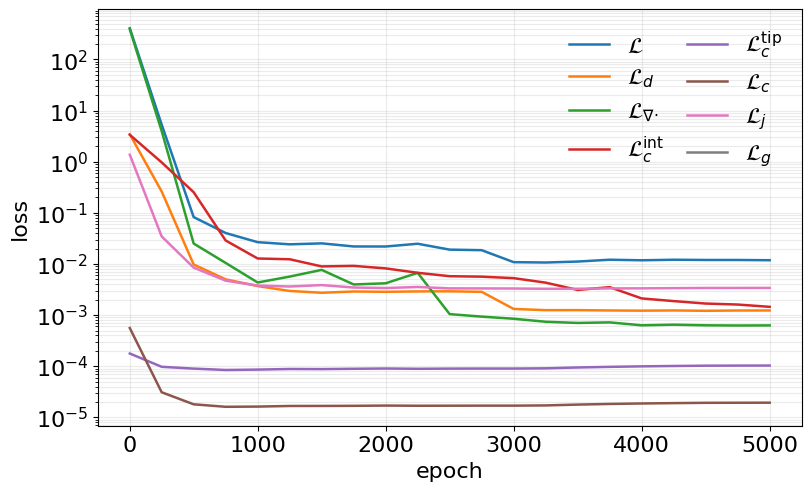

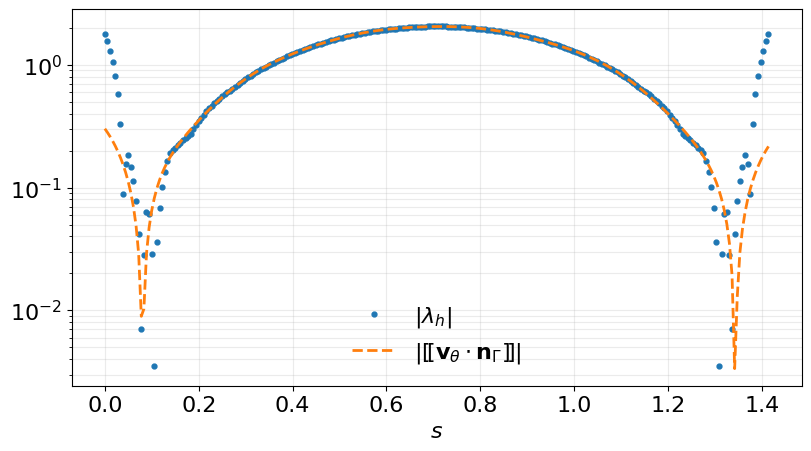

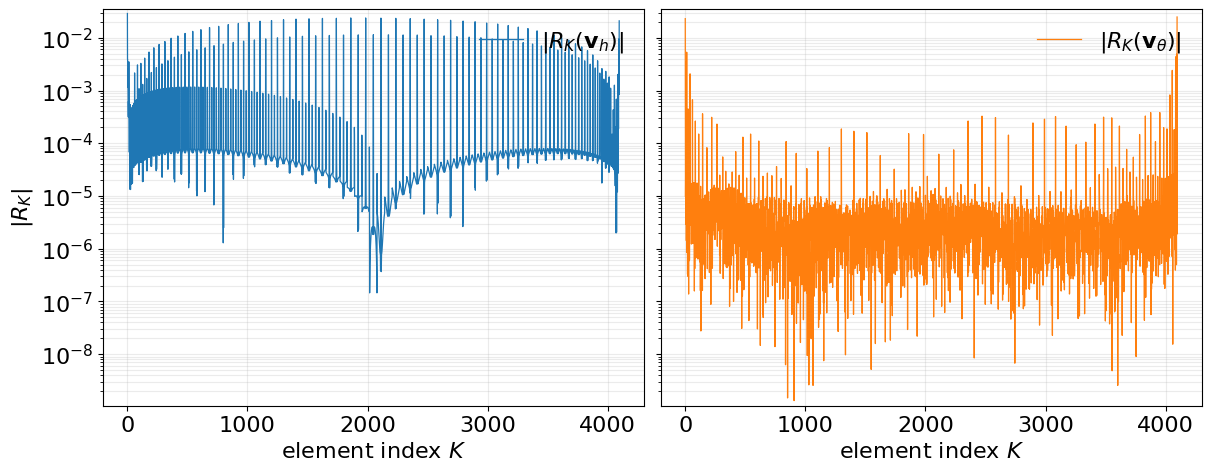

In [15]:
@torch.no_grad()
def q_rec_numpy(points):
    return q_piecewise(to_torch(points)).detach().cpu().numpy()

@torch.no_grad()
def jump_rec_numpy(s):
    xq = real_points_np(np.asarray(s, dtype=float).reshape(-1))
    return torch.sum(
        (q_plus(to_torch(xq)) - q_minus(to_torch(xq))) * normal_t.reshape(1, 2), dim=1
    ).detach().cpu().numpy()

def residual_for_cell_data_numpy(cell_ids):
    data = attach_gamma_facets_to_cell_data(build_edge_quadrature_for_cells(cell_ids))
    # Match loss_cons_frac: for fracture-adjacent cells, the fracture
    # edge is not a boundary-flux edge; lambda_h_int is the source term.
    active = ~data["is_gamma_edge"]

    q_edges_rec = q_rec_numpy(data["edge_points"][active])
    edge_flux_rec = np.sum(q_edges_rec * data["edge_nw"][active], axis=1)
    flux_rec = np.zeros(len(data["source"]))
    np.add.at(flux_rec, data["edge_cells"][active], edge_flux_rec)

    q_edges_cg = q_cg_numpy(data["edge_points"][active])
    edge_flux_cg = np.sum(q_edges_cg * data["edge_nw"][active], axis=1)
    flux_cg = np.zeros(len(data["source"]))
    np.add.at(flux_cg, data["edge_cells"][active], edge_flux_cg)

    R_rec = flux_rec - data["source"] - data["lambda_h_int"]
    R_cg  = flux_cg  - data["source"] - data["lambda_h_int"]
    return data, R_cg, R_rec

all_cell_ids = np.arange(num_cells)
diag_data, R_cg, R_rec = residual_for_cell_data_numpy(all_cell_ids)

print("CG local conservation:")
print("  mean |R_K|:", np.mean(np.abs(R_cg)))
print("  median |R_K|:", np.median(np.abs(R_cg)))
print("  max  |R_K|:", np.max(np.abs(R_cg)))
print("Ghost-partition PINN reconstruction:")
print("  mean |R_K|:", np.mean(np.abs(R_rec)))
print("  median |R_K|:", np.median(np.abs(R_rec)))
print("  max  |R_K|:", np.max(np.abs(R_rec)))

hist = {k: np.array([row[k] for row in history]) for k in history[0].keys()}

# Publication-style diagnostics.
pub_fs = 16
plt.rcParams.update({
    "font.size": pub_fs,
    "axes.labelsize": pub_fs,
    "axes.titlesize": pub_fs,
    "xtick.labelsize": pub_fs,
    "ytick.labelsize": pub_fs,
    "legend.fontsize": pub_fs,
})

# Training history.
loss_labels = {
    "total": r"$\mathcal{L}$",
    "data": r"$\mathcal{L}_d$",
    "div": r"$\mathcal{L}_{\nabla\!\cdot}$",
    "cons_int": r"$\mathcal{L}_c^{\mathrm{int}}$",
    "cons_tip": r"$\mathcal{L}_c^{\mathrm{tip}}$",
    "cons_frac": r"$\mathcal{L}_c$",
    "jump": r"$\mathcal{L}_j$",
    "ghost": r"$\mathcal{L}_g$",
}
fig, ax = plt.subplots(figsize=(8.0, 4.8), constrained_layout=True)
for key in ["total", "data", "div", "cons_int", "cons_tip", "cons_frac", "jump", "ghost"]:
    ax.semilogy(hist["epoch"], hist[key], lw=1.8, label=loss_labels[key])
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, which="both", alpha=0.25)
ax.legend(ncol=2, frameon=False, columnspacing=1.0, handlelength=1.8)
plt.show()

# Real-fracture jump condition.
jump_rec = jump_rec_numpy(s_real)
target_label = r"$|\lambda_h|$" if TARGET_MODE == "lambda_h" else r"$|[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]|$"
fig, ax = plt.subplots(figsize=(8.0, 4.4), constrained_layout=True)
ax.semilogy(s_real, np.abs(lambda_target) + 1e-16, "o", ms=3.5, lw=1.2, label=target_label)
ax.semilogy(s_real, np.abs(jump_rec) + 1e-16, "--", lw=2.0,
            label=r"$|[\![\mathbf{v}_\theta\cdot\mathbf{n}_\Gamma]\!]|$")
ax.set_xlabel(r"$s$")
# ax.set_ylabel("magnitude")
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False)
plt.show()

# Element residual by index: before vs after reconstruction.
rk_eps = 1e-16
rk_cg = np.abs(R_cg) + rk_eps
rk_rec = np.abs(R_rec) + rk_eps
rk_ymin = max(rk_eps, min(np.min(rk_cg), np.min(rk_rec)) * 0.8)
rk_ymax = max(np.max(rk_cg), np.max(rk_rec)) * 1.2
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6), sharey=True, constrained_layout=True)
for ax, values, label, color in [
    (axes[0], rk_cg, r"$|R_K(\mathbf{v}_h)|$", "tab:blue"),
    (axes[1], rk_rec, r"$|R_K(\mathbf{v}_\theta)|$", "tab:orange"),
]:
    ax.semilogy(np.arange(len(values)), values, lw=0.9, color=color, label=label)
    ax.set_xlabel(r"element index $K$")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(frameon=False, loc="upper right")
    ax.set_ylim(rk_ymin, rk_ymax)
axes[0].set_ylabel(r"$|R_K|$")
plt.show()


## 10. Residual maps


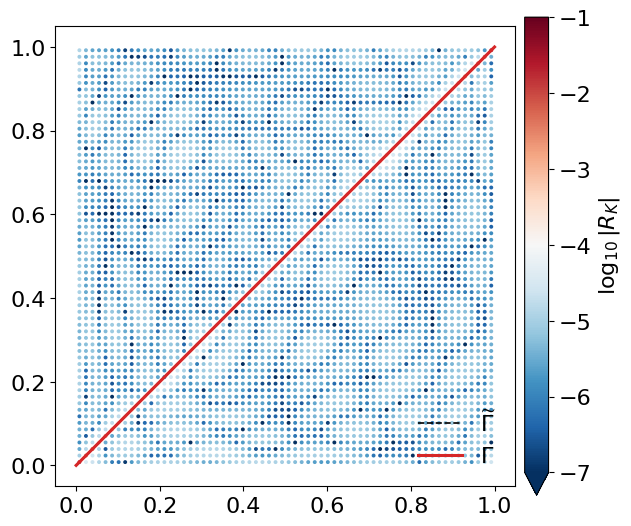

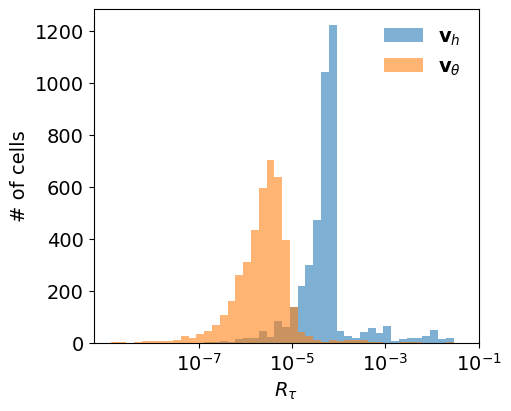

In [22]:
cent = cell_centroids[diag_data["cell_ids"]]

# Publication-style residual map after PINN reconstruction.
# The CG residual map is shown earlier in Section 5b.
# Values outside [10^{-7}, 10^{-1}] are intentionally saturated so the colorbars match.
pub_fs = 16
plt.rcParams.update({
    "font.size": pub_fs,
    "axes.labelsize": pub_fs,
    "axes.titlesize": pub_fs,
    "xtick.labelsize": pub_fs,
    "ytick.labelsize": pub_fs,
    "legend.fontsize": pub_fs,
})
rk_log_vmin = globals().get("RK_LOG_VMIN", -7.0)
rk_log_vmax = globals().get("RK_LOG_VMAX", -1.0)
rk_cbar_ticks = globals().get("RK_CBAR_TICKS", np.array([-7, -6, -5, -4, -3, -2, -1], dtype=float))
rk_log_cg = np.log10(np.abs(R_cg) + 1e-16)
rk_log_rec = np.log10(np.abs(R_rec) + 1e-16)
rk_log_min = rk_log_rec.min()
rk_log_max = rk_log_rec.max()
if rk_log_min < rk_log_vmin and rk_log_max > rk_log_vmax:
    rk_extend = "both"
elif rk_log_min < rk_log_vmin:
    rk_extend = "min"
elif rk_log_max > rk_log_vmax:
    rk_extend = "max"
else:
    rk_extend = "neither"

fig, ax = plt.subplots(figsize=(6.2, 5.2), constrained_layout=True)
sc = ax.scatter(
    cent[:, 0],
    cent[:, 1],
    c=rk_log_rec,
    s=8,
    cmap="RdBu_r",
    vmin=rk_log_vmin,
    vmax=rk_log_vmax,
    linewidths=0.0,
    rasterized=True,
)
ax.plot([GHOST_START[0], GHOST_END[0]], [GHOST_START[1], GHOST_END[1]],
        "k--", lw=1.2, label=r"$\widetilde{\Gamma}$")
ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]],
        color="tab:red", ls="-", lw=2.2, label=r"$\Gamma$")
ax.set_aspect("equal")
# ax.set_title(r"$|R_K(\mathbf{v}_\theta)|$")
# ax.set_xlabel(r"$x$")
# ax.set_ylabel(r"$y$")
ax.grid(False)
ax.legend(frameon=False, loc="lower right", handlelength=2.0)
cbar = fig.colorbar(sc, ax=ax, label=r"$\log_{10}|R_K|$", extend=rk_extend, pad=0.02)
cbar.set_ticks(rk_cbar_ticks)
plt.show()

lo = min(rk_log_cg.min(), rk_log_rec.min())
hi = max(rk_log_cg.max(), rk_log_rec.max())
bins = np.linspace(lo, hi, 45)
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ax.hist(rk_log_cg, bins=bins, alpha=0.58, label=r"$\mathbf{v}_h$", color="tab:blue")
ax.hist(rk_log_rec, bins=bins, alpha=0.58, label=r"$\mathbf{v}_\theta$", color="tab:orange")
ax.set_xlabel(r"$R_\tau$", fontsize=14)
rk_hist_ticks = rk_cbar_ticks[::2]
ax.set_xticks(rk_hist_ticks)
ax.set_xticklabels([r"$10^{%d}$" % int(t) for t in rk_hist_ticks])
ax.tick_params(labelsize=14)
ax.set_ylabel("# of cells", fontsize=14)
ax.grid(False)
ax.legend(frameon=False, fontsize=14)
plt.show()


Interior control-volume residual R_xi (Deng-style vertex dual cells)
CG flux $\mathbf{v}_h$
  mean |R_xi|   = 2.399805e-04
  median |R_xi| = 4.498441e-07
  max  |R_xi|   = 1.431201e-02
PINN reconstruction $\mathbf{v}_\theta$
  mean |R_xi|   = 1.710478e-05
  median |R_xi| = 2.690545e-06
  max  |R_xi|   = 1.482574e-02


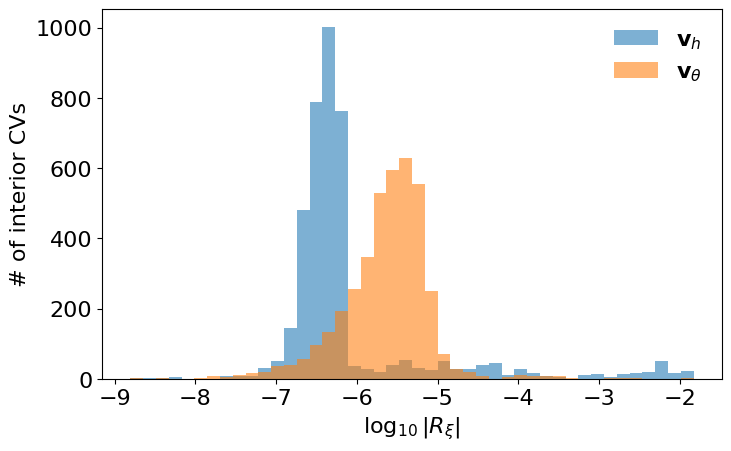

In [17]:
# Deng-style vertex control-volume residual R_xi.
def rxi_normal_from_C_to_ti(centroid, midpoint, vi):
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1e-30)

def rxi_point_in_convex_polygon(pt, poly, tol=1e-12):
    pt = np.asarray(pt, dtype=float)[:2]
    poly = np.asarray(poly, dtype=float)[:, :2]
    for j in range(len(poly)):
        a = poly[j]
        b = poly[(j + 1) % len(poly)]
        edge = b - a
        cross = edge[0] * (pt[1] - a[1]) - edge[1] * (pt[0] - a[0])
        if cross < -tol:
            return False
    return True

def rxi_segment_edge_s_candidates(a, b, s_min, s_max, tol=1e-12):
    a = np.asarray(a, dtype=float)[:2]
    b = np.asarray(b, dtype=float)[:2]
    edge = b - a
    A = np.column_stack((tau_np, -edge))
    rhs = a - FRAC_A
    det = np.linalg.det(A)
    if abs(det) < tol:
        if max(abs(np.dot(a - FRAC_A, normal_np)), abs(np.dot(b - FRAC_A, normal_np))) > 10.0 * tol:
            return []
        sa = float(s_coord_np(a[None, :])[0])
        sb = float(s_coord_np(b[None, :])[0])
        lo = max(min(sa, sb), s_min)
        hi = min(max(sa, sb), s_max)
        return [lo, hi] if hi - lo > tol else []
    s, u = np.linalg.solve(A, rhs)
    if s_min - tol <= s <= s_max + tol and -tol <= u <= 1.0 + tol:
        return [float(np.clip(s, s_min, s_max))]
    return []

def rxi_fracture_intervals_in_polygon(poly, s_min=0.0, s_max=None, tol=1e-11):
    poly = order_polygon_vertices(np.asarray(poly, dtype=float)[:, :2])
    if s_max is None:
        s_max = L_gamma
    s_min = max(0.0, float(s_min))
    s_max = min(float(L_gamma), float(s_max))
    if s_max - s_min <= tol:
        return []
    candidates = [s_min, s_max]
    for j in range(len(poly)):
        candidates.extend(rxi_segment_edge_s_candidates(poly[j], poly[(j + 1) % len(poly)], s_min, s_max, tol=tol))
    candidates = sorted(candidates)
    unique = []
    for s in candidates:
        if not unique or abs(s - unique[-1]) > tol:
            unique.append(float(s))
    intervals = []
    for s0, s1 in zip(unique[:-1], unique[1:]):
        if s1 - s0 <= tol:
            continue
        sm = 0.5 * (s0 + s1)
        if rxi_point_in_convex_polygon(real_points_np([sm])[0], poly, tol=1e-10):
            intervals.append((float(s0), float(s1)))
    return intervals

def rxi_integrate_lambda_interval(s0, s1):
    if s1 - s0 <= 0.0:
        return 0.0
    mid = 0.5 * (s0 + s1)
    half = 0.5 * (s1 - s0)
    sq = mid + half * np.array([-1.0 / np.sqrt(3.0), 1.0 / np.sqrt(3.0)])
    return float(half * np.sum(lambda_h_on_s(sq)))

def rxi_integrate_source_polygon(poly):
    if "integrate_source_polygon" in globals():
        return float(integrate_source_polygon(poly))
    bary = globals().get("SOURCE_BARY", globals().get("TRI_BARY"))
    weights = globals().get("SOURCE_WEIGHTS", globals().get("TRI_WEIGHTS"))
    if bary is None or weights is None:
        raise RuntimeError("No triangle source quadrature rule is available.")
    poly = order_polygon_vertices(np.asarray(poly, dtype=float)[:, :2])
    total = 0.0
    p0 = poly[0]
    for j in range(1, len(poly) - 1):
        tri = np.vstack([p0, poly[j], poly[j + 1]])
        area = abs(polygon_signed_area(tri))
        qpts = bary @ tri
        vals = np.asarray(f_m_exact_points(qpts), dtype=float).reshape(-1)
        total += area * float(np.dot(weights, vals))
    return float(total)

def build_rxi_cv_residuals():
    vertex_key_to_id = {}
    vertices_xy = []
    cell_vertex_ids = []

    def get_vid(xy):
        key = tuple(np.round(np.asarray(xy, dtype=float)[:2], 12))
        if key not in vertex_key_to_id:
            vertex_key_to_id[key] = len(vertices_xy)
            vertices_xy.append(np.asarray(xy, dtype=float)[:2])
        return vertex_key_to_id[key]

    for poly_raw in cell_polys:
        poly = order_polygon_vertices(np.asarray(poly_raw, dtype=float)[:, :2])
        cell_vertex_ids.append(np.array([get_vid(xy) for xy in poly], dtype=np.int32))

    n_vertices = len(vertices_xy)
    flux_cg = np.zeros(n_vertices, dtype=float)
    flux_rec = np.zeros(n_vertices, dtype=float)
    source = np.zeros(n_vertices, dtype=float)
    lambda_src = np.zeros(n_vertices, dtype=float)
    edge_points = []
    edge_nw = []
    edge_vids = []
    gamma_by_cell = {}
    for cell_id, s0, s1, seg_len in gamma_facet_records:
        denom = max(float(s1) - float(s0), 1e-30)
        gamma_by_cell.setdefault(int(cell_id), []).append((float(s0), float(s1), float(seg_len) / denom))

    g3 = np.array([0.1127016653792583, 0.5, 0.8872983346207417], dtype=float)
    w3 = np.array([5.0 / 18.0, 8.0 / 18.0, 5.0 / 18.0], dtype=float)
    for cell_id, poly_raw in enumerate(cell_polys):
        poly = order_polygon_vertices(np.asarray(poly_raw, dtype=float)[:, :2])
        centroid = poly.mean(axis=0)
        vids = cell_vertex_ids[cell_id]
        nloc = len(poly)
        for j, vid in enumerate(vids):
            vi = poly[j]
            mid_next = 0.5 * (vi + poly[(j + 1) % nloc])
            mid_prev = 0.5 * (vi + poly[(j - 1) % nloc])
            cv_poly = order_polygon_vertices(np.vstack([vi, mid_next, centroid, mid_prev]))
            source[vid] += rxi_integrate_source_polygon(cv_poly)
            for s0, s1, factor in gamma_by_cell.get(cell_id, []):
                for a, b in rxi_fracture_intervals_in_polygon(cv_poly, s0, s1):
                    lambda_src[vid] += factor * rxi_integrate_lambda_interval(a, b)
            for midp in (mid_next, mid_prev):
                seg = midp - centroid
                seg_len = float(np.linalg.norm(seg))
                if seg_len <= 1e-30:
                    continue
                n_unit = rxi_normal_from_C_to_ti(centroid, midp, vi)
                pts = centroid[None, :] + g3[:, None] * seg[None, :]
                nw = w3[:, None] * n_unit[None, :] * seg_len
                edge_points.append(pts)
                edge_nw.append(nw)
                edge_vids.extend([int(vid)] * len(g3))

    edge_points = np.vstack(edge_points)
    edge_nw = np.vstack(edge_nw)
    edge_vids = np.asarray(edge_vids, dtype=np.int32)
    q_cg_edge = q_cg_numpy(edge_points)
    q_rec_edge = q_rec_numpy(edge_points)
    np.add.at(flux_cg, edge_vids, np.sum(q_cg_edge * edge_nw, axis=1))
    np.add.at(flux_rec, edge_vids, np.sum(q_rec_edge * edge_nw, axis=1))
    return {
        "vertices_xy": np.asarray(vertices_xy, dtype=float),
        "cell_vertex_ids": cell_vertex_ids,
        "flux_cg": flux_cg,
        "flux_rec": flux_rec,
        "source": source,
        "lambda_src": lambda_src,
    }, flux_cg - source - lambda_src, flux_rec - source - lambda_src

def rxi_boundary_vertex_mask(vertices_xy):
    xy = np.asarray(vertices_xy, dtype=float)
    x0 = globals().get("xmin", float(xy[:, 0].min()))
    x1 = globals().get("xmax", float(xy[:, 0].max()))
    y0 = globals().get("ymin", float(xy[:, 1].min()))
    y1 = globals().get("ymax", float(xy[:, 1].max()))
    tol = 1e-12
    return (np.isclose(xy[:, 0], x0, atol=tol) | np.isclose(xy[:, 0], x1, atol=tol) |
            np.isclose(xy[:, 1], y0, atol=tol) | np.isclose(xy[:, 1], y1, atol=tol))

def rxi_print_stats(label, values, ids):
    vals = np.abs(np.asarray(values, dtype=float)[ids])
    print(label)
    print(f"  mean |R_xi|   = {np.mean(vals):.6e}")
    print(f"  median |R_xi| = {np.median(vals):.6e}")
    print(f"  max  |R_xi|   = {np.max(vals):.6e}")

rxi_data, R_xi_cg, R_xi_rec = build_rxi_cv_residuals()
rxi_is_boundary = rxi_boundary_vertex_mask(rxi_data["vertices_xy"])
rxi_interior_ids = np.where(~rxi_is_boundary)[0]

print("Interior control-volume residual R_xi (Deng-style vertex dual cells)")
rxi_print_stats(r"CG flux $\mathbf{v}_h$", R_xi_cg, rxi_interior_ids)
rxi_print_stats(r"PINN reconstruction $\mathbf{v}_\theta$", R_xi_rec, rxi_interior_ids)

rxi_log_cg = np.log10(np.abs(R_xi_cg[rxi_interior_ids]) + 1e-16)
rxi_log_rec = np.log10(np.abs(R_xi_rec[rxi_interior_ids]) + 1e-16)
lo = min(rxi_log_cg.min(), rxi_log_rec.min())
hi = max(rxi_log_cg.max(), rxi_log_rec.max())
bins = np.linspace(lo, hi, 45)
fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
ax.hist(rxi_log_cg, bins=bins, alpha=0.58, label=r"$\mathbf{v}_h$", color="tab:blue")
ax.hist(rxi_log_rec, bins=bins, alpha=0.58, label=r"$\mathbf{v}_\theta$", color="tab:orange")
ax.set_xlabel(r"$\log_{10}|R_\xi|$")
ax.set_ylabel("# of interior CVs")
ax.grid(False)
ax.legend(frameon=False)
plt.show()


## 11. Save model and arrays


In [18]:
import pathlib

outdir_rec = pathlib.Path("result_ghost_partition_pinn_nonconforming")
outdir_rec.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "q_plus": q_plus_net.state_dict(),
        "q_minus": q_minus_net.state_dict(),
        "FRAC_A": FRAC_A,
        "FRAC_B": FRAC_B,
        "GHOST_START": GHOST_START,
        "GHOST_END": GHOST_END,
        "normal": normal_np,
        "tau": tau_np,
        "LAMBDA_SIGN": LAMBDA_SIGN,
        "TARGET_MODE": TARGET_MODE,
        "CONSERVATION_TARGET": CONSERVATION_TARGET,
        "xy_center": xy_center_np,
        "xy_scale": xy_scale,
    },
    outdir_rec / "ghost_partition_pinn_flux.pt",
)

np.savez(
    outdir_rec / "diagnostics.npz",
    cell_ids=diag_data["cell_ids"],
    centroids=cent,
    R_cg=R_cg,
    R_rec=R_rec,
    R_xi_cg=globals().get("R_xi_cg", np.array([])),
    R_xi_rec=globals().get("R_xi_rec", np.array([])),
    rxi_vertices=globals().get("rxi_data", {}).get("vertices_xy", np.zeros((0, 2))),
    rxi_interior_ids=globals().get("rxi_interior_ids", np.array([], dtype=np.int32)),
    s_real=s_real,
    lambda_target=lambda_target,
    jump_rec=jump_rec,
)

print("saved to", outdir_rec.resolve())


saved to /home/muchamad/PhD/fenicsx/code/fracture problem/result_ghost_partition_pinn_nonconforming


## 12. Jump diagnostics: real fracture and ghost extension

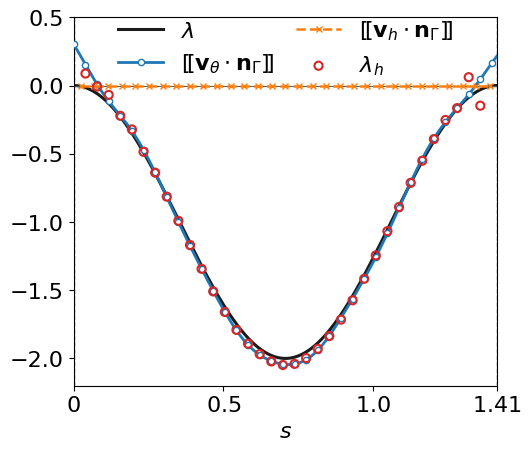

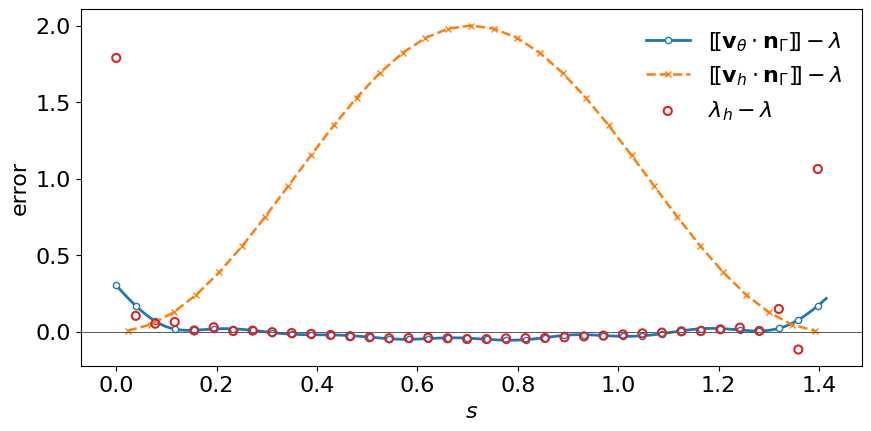

No ghost extension points: physical fracture spans the full ghost line.


In [19]:
@torch.no_grad()
def jump_and_sides_numpy(pts):
    x_t = to_torch(pts)
    qp = q_plus(x_t).cpu().numpy()
    qm = q_minus(x_t).cpu().numpy()
    qp_n = qp @ normal_np
    qm_n = qm @ normal_np
    return qp_n, qm_n, qp_n - qm_n

# Arc-length coordinates.
s_ghost_all = s_coord_np(x_ghost)
mask_left = s_ghost_all < 0.0
mask_right = s_ghost_all > L_gamma
x_ghost_left = x_ghost[mask_left]; s_ghost_left = s_ghost_all[mask_left]
x_ghost_right = x_ghost[mask_right]; s_ghost_right = s_ghost_all[mask_right]

# PINN jumps.
qp_n_real, qm_n_real, jump_pinn_real = jump_and_sides_numpy(x_real)
_, _, jump_pinn_gl = jump_and_sides_numpy(x_ghost_left) if len(x_ghost_left) else (None, None, np.array([]))
_, _, jump_pinn_gr = jump_and_sides_numpy(x_ghost_right) if len(x_ghost_right) else (None, None, np.array([]))

# CG jumps. On the physical fracture, use the same midpoint grid as Section 5.
dof_xy_jump = V_l.tabulate_dof_coordinates()
s_l_jump = np.sort(s_coord_np(dof_xy_jump))
s_mid_jump = 0.5 * (s_l_jump[:-1] + s_l_jump[1:])
jump_cg_mid = cg_jump_on_fracture(s_mid_jump)
lambda_exact_mid = lambda_exact_points(real_points_np(s_mid_jump))
jump_cg_gl = cg_jump_on_fracture(s_ghost_left) if len(s_ghost_left) else np.array([])
jump_cg_gr = cg_jump_on_fracture(s_ghost_right) if len(s_ghost_right) else np.array([])

lambda_h_real = LAMBDA_SIGN * eval_fem_function(lmbd, x_real, gamma).reshape(-1)
lambda_exact_real = lambda_exact_points(x_real)

s_full = np.concatenate([s_ghost_left, s_real, s_ghost_right])
s_cg_full = np.concatenate([s_ghost_left, s_mid_jump, s_ghost_right])
jump_pinn_all = np.concatenate([jump_pinn_gl, jump_pinn_real, jump_pinn_gr])
jump_cg_all = np.concatenate([jump_cg_gl, jump_cg_mid, jump_cg_gr])

# Publication-style jump diagnostics.
pub_fs = 16
plt.rcParams.update({
    "font.size": pub_fs,
    "axes.labelsize": pub_fs,
    "axes.titlesize": pub_fs,
    "xtick.labelsize": pub_fs,
    "ytick.labelsize": pub_fs,
    "legend.fontsize": pub_fs,
})
jump_label = r"$[\![\mathbf{v}\cdot\mathbf{n}_\Gamma]\!]$"
jump_theta_label = r"$[\![\mathbf{v}_\theta\cdot\mathbf{n}_\Gamma]\!]$"
jump_h_label = r"$[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]$"

# Signed jump along the ghost line.
fig, ax = plt.subplots(figsize=(5.2, 4.4), constrained_layout=True)
mark_full = max(len(s_full) // 34, 1)
mark_cg_full = max(len(s_cg_full) // 34, 1)
mark_real = max(len(s_real) // 34, 1)
ax.plot(s_real, lambda_exact_real, color="0.10", lw=2.2, ls="-", label=r"$\lambda$", zorder=2)
ax.plot(
    s_full, jump_pinn_all,
    color="tab:blue", lw=2.0, marker="o", ms=4.5, markevery=mark_full,
    mfc="white", mec="tab:blue", label=jump_theta_label, zorder=3,
)
ax.plot(
    s_cg_full, jump_cg_all,
    color="tab:orange", lw=1.8, ls="--", marker="x", ms=5.0, markevery=mark_cg_full,
    label=jump_h_label, zorder=3,
)
ax.scatter(
    s_real[::mark_real], lambda_h_real[::mark_real],
    s=34, facecolors="none", edgecolors="tab:red", linewidths=1.5,
    label=r"$\lambda_h$", zorder=4,
)
ax.axvline(0.0, color="k", lw=0.9, ls="--")
ax.axvline(L_gamma, color="k", lw=0.9, ls="--")
ax.axhline(0.0, color="0.35", lw=0.7)
jump_y_lo = min(lambda_exact_real.min(), lambda_h_real.min(), jump_pinn_all.min(), jump_cg_all.min())
jump_y_hi = max(lambda_exact_real.max(), lambda_h_real.max(), jump_pinn_all.max(), jump_cg_all.max())
jump_y_pad_lo = 0.08 * max(jump_y_hi - jump_y_lo, 1e-6)
# ax.set_ylim(jump_y_lo - jump_y_pad_lo, jump_y_hi + 0.2)
ax.set_ylim(-2.2, 0.5)
ax.set_xlim(0.0, L_gamma)
ax.set_xticks([0.0, 0.5, 1.0, L_gamma])
ax.set_xticklabels([r"$0$", r"$0.5$", r"$1.0$", rf"${L_gamma:.2f}$"])
ax.set_xlabel(r"$s$")
# ax.set_ylabel(jump_label)
ax.legend(
    frameon=False, ncol=2, columnspacing=1.0, handlelength=2.0,
    loc="upper center", bbox_to_anchor=(0.5, 1.02), borderaxespad=0.0,
)
ax.grid(False)
plt.show()

# Pointwise jump error on the real fracture.
fig, ax = plt.subplots(figsize=(8.6, 4.2), constrained_layout=True)
mark_real = max(len(s_real) // 34, 1)
mark_mid = max(len(s_mid_jump) // 34, 1)
ax.plot(
    s_real, jump_pinn_real - lambda_exact_real,
    color="tab:blue", lw=2.0, marker="o", ms=4.5, markevery=mark_real,
    mfc="white", mec="tab:blue",
    label=r"$[\![\mathbf{v}_\theta\cdot\mathbf{n}_\Gamma]\!]-\lambda$",
)
ax.plot(
    s_mid_jump, jump_cg_mid - lambda_exact_mid,
    color="tab:orange", lw=1.8, ls="--", marker="x", ms=5.0, markevery=mark_mid,
    label=r"$[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]-\lambda$",
)
ax.scatter(
    s_real[::mark_real], (lambda_h_real - lambda_exact_real)[::mark_real],
    s=34, facecolors="none", edgecolors="tab:red", linewidths=1.5,
    label=r"$\lambda_h-\lambda$", zorder=4,
)
ax.axhline(0.0, color="0.35", lw=0.7)
ax.set_xlabel(r"$s$")
ax.set_ylabel("error")
ax.legend(frameon=False, ncol=1, handlelength=2.0)
ax.grid(False)
plt.show()

# Ghost-extension jump magnitude, if the ghost extension exists.
s_ghost_only = np.concatenate([s_ghost_left, s_ghost_right])
jp_ghost_only = np.concatenate([jump_pinn_gl, jump_pinn_gr])
jcg_ghost_only = np.concatenate([jump_cg_gl, jump_cg_gr])

if len(s_ghost_only):
    fig, ax = plt.subplots(figsize=(8.6, 4.2), constrained_layout=True)
    ax.semilogy(s_ghost_only, np.abs(jp_ghost_only) + 1e-16,
                color="tab:blue", lw=1.8, label=r"$|[\![\mathbf{v}_\theta\cdot\mathbf{n}_\Gamma]\!]|$")
    ax.semilogy(s_ghost_only, np.abs(jcg_ghost_only) + 1e-16,
                color="tab:orange", lw=1.8, ls="--", label=r"$|[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]|$")
    ax.set_xlabel(r"$s$")
    ax.set_ylabel("magnitude")
    ax.legend(frameon=False, handlelength=2.0)
    ax.grid(True, which="both", alpha=0.22)
    plt.show()
else:
    print("No ghost extension points: physical fracture spans the full ghost line.")


## 13. Local conservation around fracture and ghost extension


Fracture-adjacent cells: 64
Ghost extension cells   : 0


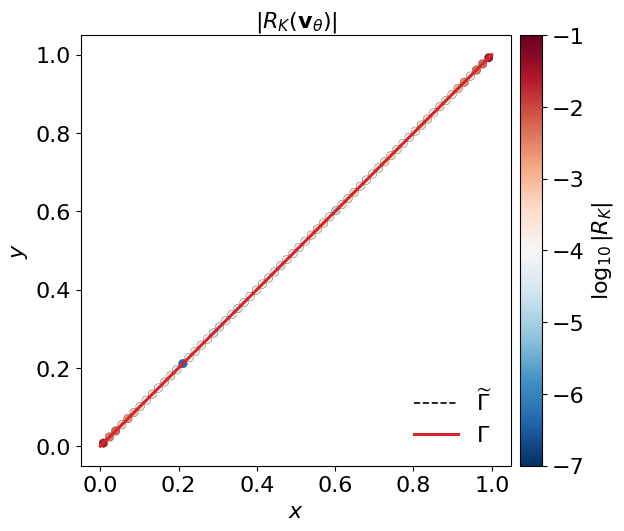

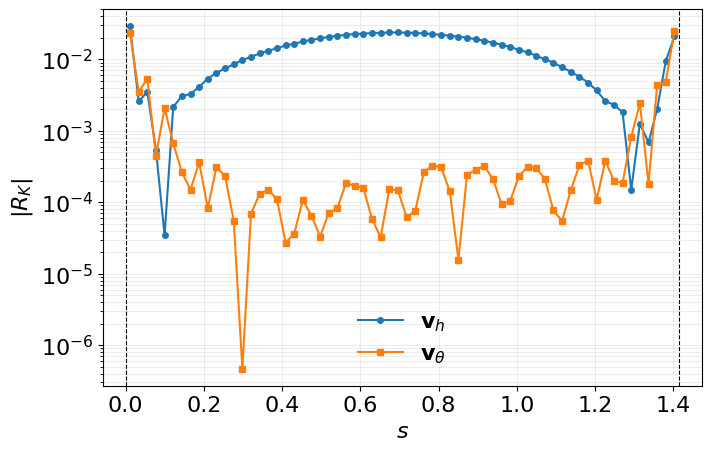


Fracture-adjacent cells  (n=64):
  CG   mean|R| = 1.275e-02   max|R| = 2.884e-02
  PINN mean|R| = 1.267e-03   max|R| = 2.477e-02

Ghost extension cells: none


In [20]:
# Identify fracture-adjacent cells.
frac_cell_ids = np.unique([cell_id for cell_id, _, _, _ in gamma_facet_records])

# Identify ghost extension cells (near ghost line, outside physical fracture).
# For the full diagonal MMS, this should be empty because the physical
# fracture spans the whole ghost line inside the unit square.
d_ghost_thresh = 2.5 * h_est
phi_cent_all = signed_distance_np(cell_centroids)
s_cent_all   = s_coord_np(cell_centroids)
ghost_mask = (
    (np.abs(phi_cent_all) < d_ghost_thresh) &
    ((s_cent_all < 0.0) | (s_cent_all > L_gamma))
)
ghost_cell_ids = np.where(ghost_mask)[0]

# R_cg / R_rec are indexed directly by cell index (diag_data['cell_ids'] = arange).
R_cg_frac   = R_cg[frac_cell_ids]
R_rec_frac  = R_rec[frac_cell_ids]
R_cg_ghost  = R_cg[ghost_cell_ids]
R_rec_ghost = R_rec[ghost_cell_ids]

cent_frac  = cell_centroids[frac_cell_ids]
cent_ghost = cell_centroids[ghost_cell_ids]
s_frac     = s_coord_np(cent_frac)
s_ghost    = s_coord_np(cent_ghost) if len(cent_ghost) else np.array([])

print(f"Fracture-adjacent cells: {len(frac_cell_ids)}")
print(f"Ghost extension cells   : {len(ghost_cell_ids)}")

if len(ghost_cell_ids):
    all_ids   = np.concatenate([frac_cell_ids, ghost_cell_ids])
    all_cent  = cell_centroids[all_ids]
    all_R_cg  = np.concatenate([R_cg_frac, R_cg_ghost])
    all_R_rec = np.concatenate([R_rec_frac, R_rec_ghost])
else:
    all_ids   = frac_cell_ids
    all_cent  = cent_frac
    all_R_cg  = R_cg_frac
    all_R_rec = R_rec_frac

# Publication-style local residual diagnostics.
pub_fs = 16
plt.rcParams.update({
    "font.size": pub_fs,
    "axes.labelsize": pub_fs,
    "axes.titlesize": pub_fs,
    "xtick.labelsize": pub_fs,
    "ytick.labelsize": pub_fs,
    "legend.fontsize": pub_fs,
})
rk_log_vmin = globals().get("RK_LOG_VMIN", -7.0)
rk_log_vmax = globals().get("RK_LOG_VMAX", -1.0)
rk_cbar_ticks = globals().get("RK_CBAR_TICKS", np.array([-7, -6, -5, -4, -3, -2, -1], dtype=float))
rk_log_rec_local = np.log10(np.abs(all_R_rec) + 1e-16)
rk_log_min = rk_log_rec_local.min()
rk_log_max = rk_log_rec_local.max()
if rk_log_min < rk_log_vmin and rk_log_max > rk_log_vmax:
    rk_extend = "both"
elif rk_log_min < rk_log_vmin:
    rk_extend = "min"
elif rk_log_max > rk_log_vmax:
    rk_extend = "max"
else:
    rk_extend = "neither"

# Map: reconstructed residual only. The corresponding CG residual map is shown in Section 5b.
fig, ax = plt.subplots(figsize=(6.2, 5.2), constrained_layout=True)
sc = ax.scatter(
    all_cent[:, 0],
    all_cent[:, 1],
    c=rk_log_rec_local,
    s=38,
    cmap="RdBu_r",
    vmin=rk_log_vmin,
    vmax=rk_log_vmax,
    edgecolors="k",
    linewidths=0.2,
    rasterized=True,
)
ax.plot([GHOST_START[0], GHOST_END[0]], [GHOST_START[1], GHOST_END[1]],
        "k--", lw=1.2, label=r"$\widetilde{\Gamma}$")
ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]],
        color="tab:red", ls="-", lw=2.2, label=r"$\Gamma$")
ax.set_aspect("equal")
ax.set_title(r"$|R_K(\mathbf{v}_\theta)|$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.grid(False)
ax.legend(frameon=False, loc="lower right", handlelength=2.0)
cbar = fig.colorbar(sc, ax=ax, label=r"$\log_{10}|R_K|$", extend=rk_extend, pad=0.02)
cbar.set_ticks(rk_cbar_ticks)
plt.show()

# Residuals versus arclength: keep CG and reconstructed residuals for comparison.
ncols = 2 if len(ghost_cell_ids) else 1
fig, axes = plt.subplots(1, ncols, figsize=(7.0 * ncols, 4.4), constrained_layout=True)
if ncols == 1:
    axes = [axes]

panels = [(axes[0], R_cg_frac, R_rec_frac, s_frac, "fracture-cut")]
if len(ghost_cell_ids):
    panels.append((axes[1], R_cg_ghost, R_rec_ghost, s_ghost, "ghost extension"))

for ax, R_cg_f, R_rec_f, s_f, label in panels:
    sort_idx = np.argsort(s_f)
    ax.semilogy(s_f[sort_idx], np.abs(R_cg_f[sort_idx]) + 1e-16,
                "o-", ms=4, lw=1.5, label=r"$\mathbf{v}_h$")
    ax.semilogy(s_f[sort_idx], np.abs(R_rec_f[sort_idx]) + 1e-16,
                "s-", ms=4, lw=1.5, label=r"$\mathbf{v}_\theta$")
    ax.axvline(0.0, color="k", ls="--", lw=0.8)
    ax.axvline(L_gamma, color="k", ls="--", lw=0.8)
    # ax.set_title(label)
    ax.set_xlabel(r"$s$")
    ax.set_ylabel(r"$|R_K|$")
    ax.grid(True, which="both", alpha=0.22)
    ax.legend(frameon=False, handlelength=2.0)
plt.show()

# Summary numbers.
for label, ids, R_cg_f, R_rec_f in [
    ("Fracture-adjacent", frac_cell_ids,  R_cg_frac,  R_rec_frac),
    ("Ghost extension",   ghost_cell_ids, R_cg_ghost, R_rec_ghost),
]:
    if len(ids) == 0:
        print(f"\n{label} cells: none")
        continue
    print(f"\n{label} cells  (n={len(ids)}):")
    print(f"  CG   mean|R| = {np.mean(np.abs(R_cg_f)):.3e}   max|R| = {np.max(np.abs(R_cg_f)):.3e}")
    print(f"  PINN mean|R| = {np.mean(np.abs(R_rec_f)):.3e}   max|R| = {np.max(np.abs(R_rec_f)):.3e}")


### Tip vs interior contribution to plateaued losses


In [21]:
# Split the plateaued training losses into near-tip and interior parts.
# This uses the same TIP_FRAC convention as the jump/LCE diagnostics above.
tip_pt = (s_real < TIP_FRAC * L_gamma) | (s_real > (1.0 - TIP_FRAC) * L_gamma)
int_pt = ~tip_pt

err_jump = jump_rec - lambda_target
jump_terms = w_tip * err_jump**2
jump_tip_contrib = np.sum(jump_terms[tip_pt]) / len(jump_terms)
jump_int_contrib = np.sum(jump_terms[int_pt]) / len(jump_terms)

print("Jump loss split (current model, same scale as logged jump loss):")
print(f"  all mean          : {np.mean(jump_terms):.3e}")
if history:
    print(f"  last logged       : {history[-1]['jump']:.3e}")
print(f"  tip contribution : {jump_tip_contrib:.3e}  (n={np.count_nonzero(tip_pt)})")
print(f"  int contribution : {jump_int_contrib:.3e}  (n={np.count_nonzero(int_pt)})")
if np.count_nonzero(tip_pt):
    print(f"  tip mean          : {np.mean(jump_terms[tip_pt]):.3e}")
if np.count_nonzero(int_pt):
    print(f"  int mean          : {np.mean(jump_terms[int_pt]):.3e}")

tip_cell = (s_frac < TIP_FRAC * L_gamma) | (s_frac > (1.0 - TIP_FRAC) * L_gamma)
int_cell = ~tip_cell

def _print_lce_split(name, R):
    R2 = R**2
    print(f"\n{name} conservation residual split:")
    print(f"  all mean(R^2)      : {np.mean(R2):.3e}")
    if np.count_nonzero(tip_cell):
        print(f"  tip contribution  : {np.sum(R2[tip_cell]) / len(R2):.3e}  (n={np.count_nonzero(tip_cell)})")
        print(f"  tip mean(R^2)      : {np.mean(R2[tip_cell]):.3e}")
        print(f"  tip max|R|         : {np.max(np.abs(R[tip_cell])):.3e}")
    if np.count_nonzero(int_cell):
        print(f"  int contribution  : {np.sum(R2[int_cell]) / len(R2):.3e}  (n={np.count_nonzero(int_cell)})")
        print(f"  int mean(R^2)      : {np.mean(R2[int_cell]):.3e}")
        print(f"  int max|R|         : {np.max(np.abs(R[int_cell])):.3e}")
    print(f"  all mean|R|        : {np.mean(np.abs(R)):.3e}")

_print_lce_split("PINN", R_rec_frac)
_print_lce_split("CG", R_cg_frac)

if np.count_nonzero(int_cell):
    R_pin_abs = np.abs(R_rec_frac[int_cell])
    R_cg_abs = np.abs(R_cg_frac[int_cell])
    ratio = R_pin_abs / np.maximum(R_cg_abs, 1e-16)
    print("\nInterior PINN-vs-CG conservation:")
    print(f"  improved cells       : {100.0 * np.mean(R_pin_abs < R_cg_abs):.1f}%")
    print(f"  mean |PINN|/|CG|    : {np.mean(ratio):.3e}")
    print(f"  median |PINN|/|CG|  : {np.median(ratio):.3e}")
    print(f"  max |PINN|/|CG|     : {np.max(ratio):.3e}")


Jump loss split (current model, same scale as logged jump loss):
  all mean          : 3.410e-03
  last logged       : 3.408e-03
  tip contribution : 3.342e-03  (n=52)
  int contribution : 6.810e-05  (n=204)
  tip mean          : 1.645e-02
  int mean          : 8.546e-05

PINN conservation residual split:
  all mean(R^2)      : 1.940e-05
  tip contribution  : 1.937e-05  (n=12)
  tip mean(R^2)      : 1.033e-04
  tip max|R|         : 2.477e-02
  int contribution  : 3.158e-08  (n=52)
  int mean(R^2)      : 3.887e-08
  int max|R|         : 3.823e-04
  all mean|R|        : 1.267e-03

CG conservation residual split:
  all mean(R^2)      : 2.307e-04
  tip contribution  : 2.172e-05  (n=12)
  tip mean(R^2)      : 1.158e-04
  tip max|R|         : 2.884e-02
  int contribution  : 2.090e-04  (n=52)
  int mean(R^2)      : 2.572e-04
  int max|R|         : 2.377e-02
  all mean|R|        : 1.275e-02

Interior PINN-vs-CG conservation:
  improved cells       : 100.0%
  mean |PINN|/|CG|    : 2.256e-02
  m